In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score
from matplotlib.colors import Normalize
import warnings

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded and ready!")

✓ Libraries loaded and ready!


---
# 📊 PART 1: The Dataset

Before diving into insights, let's understand what we're working with.

In [ ]:
# Load the dataset
df = pd.read_csv('Mouza_Census_PCADimension.csv')

# Identify our development dimensions
index_cols = [col for col in df.columns if '_Index' in col]

# Calculate overall development score for each district
df['Composite_Score'] = df[index_cols].mean(axis=1)

# Create consistent color mapping for provinces
# Punjab: Green, Sindh: Pink, Balochistan: Orange, KPK: Brown,
# AJK: Blue, Gilgit-Baltistan: Purple, Islamabad: Red
PROVINCE_COLORS = {
    'PUNJAB': '#2e7d32',                    # Green
    'SINDH': '#ec407a',                     # Pink
    'BALOCHISTAN': '#ff6f00',               # Orange
    'KHYBER PAKHTUNKHWA': '#795548',        # Brown
    'AZAD JAMMU AND KASHMIR': '#1976d2',    # Blue
    'GILGIT BALTISTAN': '#7b1fa2',          # Purple
    'ISLAMABAD CAPITAL TERRITORY': '#c62828' # Red
}

print("="*90)
print("PAKISTAN DISTRICT DEVELOPMENT DATA")
print("="*90)
print(f"\n📍 We're analyzing {df.shape[0]} districts across {df['Name of Province'].nunique()} provinces")
print(f"📊 Each district is measured on {len(index_cols)} development dimensions:")
print()
for i, col in enumerate(index_cols, 1):
    dimension = col.replace('_Index', '').replace('_', ' ')
    print(f"   {i:2d}. {dimension}")

print(f"\n🎯 Overall Development Score: Average of all 11 dimensions (0-100 scale)")
print(f"   • Higher scores = Better overall development")
print(f"   • National average: {df['Composite_Score'].mean():.1f}")
print(f"   • Range: {df['Composite_Score'].min():.1f} to {df['Composite_Score'].max():.1f}")

PAKISTAN DISTRICT DEVELOPMENT DATA

📍 We're analyzing 151 districts across 7 provinces
📊 Each district is measured on 11 development dimensions:

    1. Settlement
    2. Agriculture Livestock
    3. Housing Amenities
    4. Infrastructure Services
    5. Education
    6. Health
    7. Recreation Sports
    8. Social Community
    9. Industry
   10. Credit Finance
   11. Disaster Resilience

🎯 Overall Development Score: Average of all 11 dimensions (0-100 scale)
   • Higher scores = Better overall development
   • National average: 38.2
   • Range: 19.1 to 58.5


---
# 📊 PART 2: Understanding Each Development Dimension

Before looking at overall performance, let's understand how districts and provinces perform in each of the 11 individual development dimensions.

## Q1: Setting up consistent colors for provinces

We'll use a consistent color scheme throughout: best province = dark green, worst = dark red.

In [ ]:
# Use the PROVINCE_COLORS already defined above (no need to redefine)
province_colors = PROVINCE_COLORS  # Keep for backward compatibility

# For consistency, order provinces alphabetically (not by performance)
province_list = sorted(df['Name of Province'].unique())
province_order = province_list

print("="*90)
print("PROVINCIAL COLOR SCHEME (consistent throughout notebook)")
print("="*90)
print("Each province has a distinct color for easy identification:")
color_map = {
    'PUNJAB': '🟢 Green',
    'SINDH': '🩷 Pink',
    'BALOCHISTAN': '🟠 Orange',
    'KHYBER PAKHTUNKHWA': '🟤 Brown',
    'AZAD JAMMU AND KASHMIR': '🔵 Blue',
    'GILGIT BALTISTAN': '🟣 Purple',
    'ISLAMABAD CAPITAL TERRITORY': '🔴 Red'
}
for prov in province_order:
    print(f"  {prov}: {color_map.get(prov, 'Color')}")

print("\n💡 Note: Colors represent provinces, NOT performance levels")
print("   Green/Red/Orange will be used separately to show trends (good/bad)")

PROVINCIAL COLOR SCHEME (consistent throughout notebook)
Each province has a distinct color for easy identification:
  AZAD JAMMU AND KASHMIR: 🔵 Blue
  BALOCHISTAN: 🟠 Orange
  GILGIT BALTISTAN: 🟣 Purple
  ISLAMABAD CAPITAL TERRITORY: 🔴 Red
  KHYBER PAKHTUNKHWA: 🟤 Brown
  PUNJAB: 🟢 Green
  SINDH: 🩷 Pink

💡 Note: Colors represent provinces, NOT performance levels
   Green/Red/Orange will be used separately to show trends (good/bad)


## Q2: How do provinces compare across each development dimension?

Let's see provincial averages for all 11 dimensions to understand regional strengths and weaknesses.

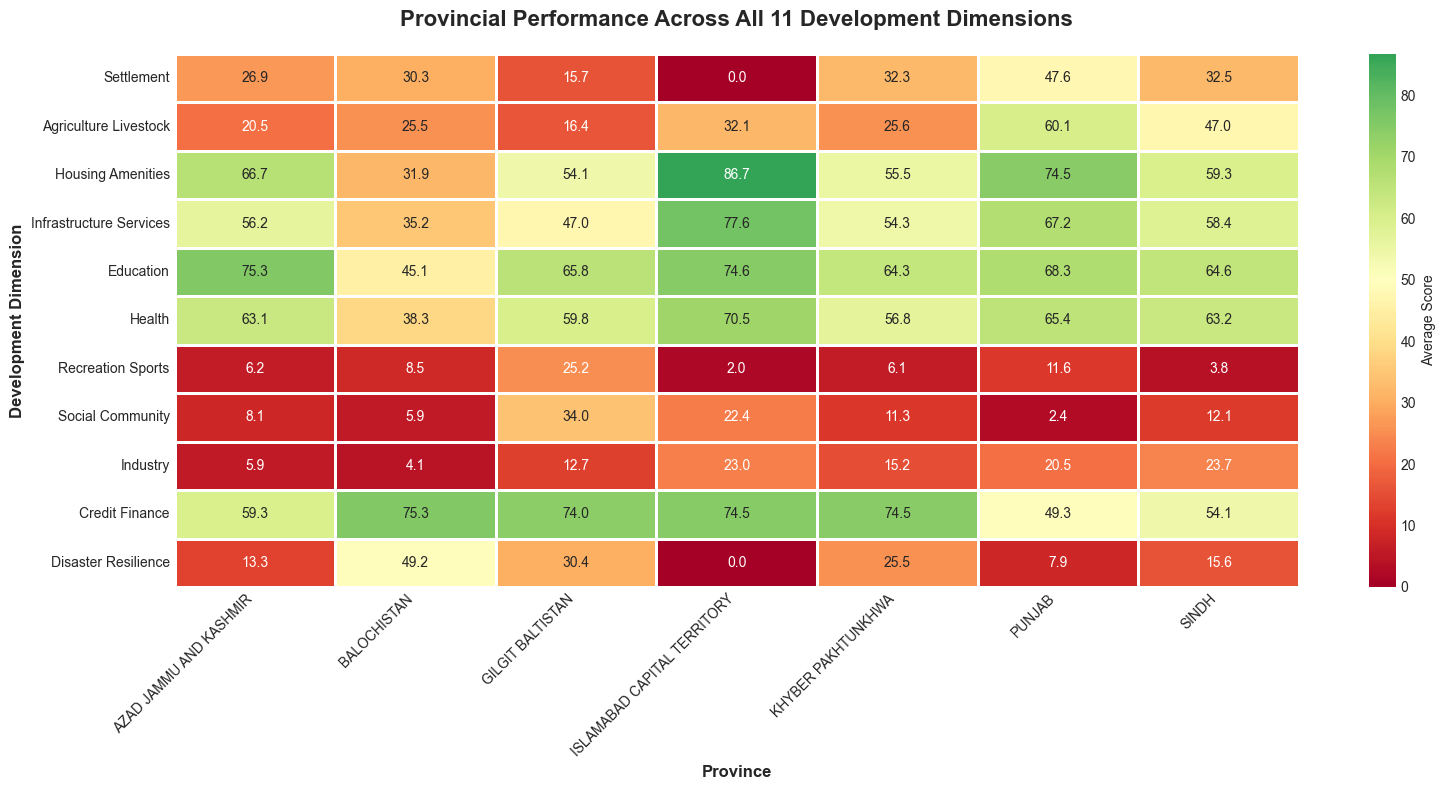


PROVINCIAL STRENGTHS AND WEAKNESSES

AZAD JAMMU AND KASHMIR:
  💪 Strongest: Education (Score: 75.3)
  ⚠️  Weakest: Industry (Score: 5.9)

BALOCHISTAN:
  💪 Strongest: Credit Finance (Score: 75.3)
  ⚠️  Weakest: Industry (Score: 4.1)

GILGIT BALTISTAN:
  💪 Strongest: Credit Finance (Score: 74.0)
  ⚠️  Weakest: Industry (Score: 12.7)

ISLAMABAD CAPITAL TERRITORY:
  💪 Strongest: Housing Amenities (Score: 86.7)
  ⚠️  Weakest: Settlement (Score: 0.0)

KHYBER PAKHTUNKHWA:
  💪 Strongest: Credit Finance (Score: 74.5)
  ⚠️  Weakest: Recreation Sports (Score: 6.1)

PUNJAB:
  💪 Strongest: Housing Amenities (Score: 74.5)
  ⚠️  Weakest: Social Community (Score: 2.4)

SINDH:
  💪 Strongest: Education (Score: 64.6)
  ⚠️  Weakest: Recreation Sports (Score: 3.8)

💡 KEY INSIGHT: Each province has unique strengths and weaknesses.
   Green cells = strong performance, Red cells = needs improvement

DEEPER ANALYSIS: Provincial Specialization & Comparative Advantage

AZAD JAMMU AND KASHMIR:
  📈 Comparative Ad

In [ ]:
# Calculate provincial averages for all dimensions
province_indices = df.groupby('Name of Province')[index_cols].mean()
province_indices = province_indices.reindex(province_order)

# Heatmap showing all provinces across all dimensions
plt.figure(figsize=(16, 8))
sns.heatmap(province_indices.T, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=1, cbar_kws={'label': 'Average Score'},
            xticklabels=province_indices.index,
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Provincial Performance Across All 11 Development Dimensions', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Province', fontweight='bold', fontsize=12)
plt.ylabel('Development Dimension', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("PROVINCIAL STRENGTHS AND WEAKNESSES")
print("="*90)
for prov in province_indices.index:
    strongest = province_indices.loc[prov].idxmax().replace('_Index', '').replace('_', ' ')
    weakest = province_indices.loc[prov].idxmin().replace('_Index', '').replace('_', ' ')
    strongest_score = province_indices.loc[prov].max()
    weakest_score = province_indices.loc[prov].min()
    
    print(f"\n{prov}:")
    print(f"  💪 Strongest: {strongest} (Score: {strongest_score:.1f})")
    print(f"  ⚠️  Weakest: {weakest} (Score: {weakest_score:.1f})")

print("\n💡 KEY INSIGHT: Each province has unique strengths and weaknesses.")
print("   Green cells = strong performance, Red cells = needs improvement")

# Statistical Analysis: Calculate provincial specialization
from scipy import stats
print("\n" + "="*90)
print("DEEPER ANALYSIS: Provincial Specialization & Comparative Advantage")
print("="*90)

for prov in province_indices.index:
    scores = province_indices.loc[prov]
    # Calculate which dimensions this province performs RELATIVELY better in
    relative_performance = scores - province_indices.mean()
    top_advantages = relative_performance.nlargest(3)
    
    print(f"\n{prov}:")
    print(f"  📈 Comparative Advantages (vs national avg):")
    for dim, diff in top_advantages.items():
        dim_name = dim.replace('_Index', '').replace('_', ' ')
        print(f"     • {dim_name}: +{diff:.1f} points above avg")
    
    # Calculate coefficient of variation (consistency)
    cv = (scores.std() / scores.mean()) * 100
    consistency = "Very Consistent" if cv < 30 else "Moderate" if cv < 50 else "Highly Uneven"
    print(f"  📊 Development Balance: {consistency} (CV: {cv:.1f}%)")

## Q3: Let's look at each dimension individually - where do provinces stand?

We'll create bar charts for each of the 11 dimensions showing provincial rankings.

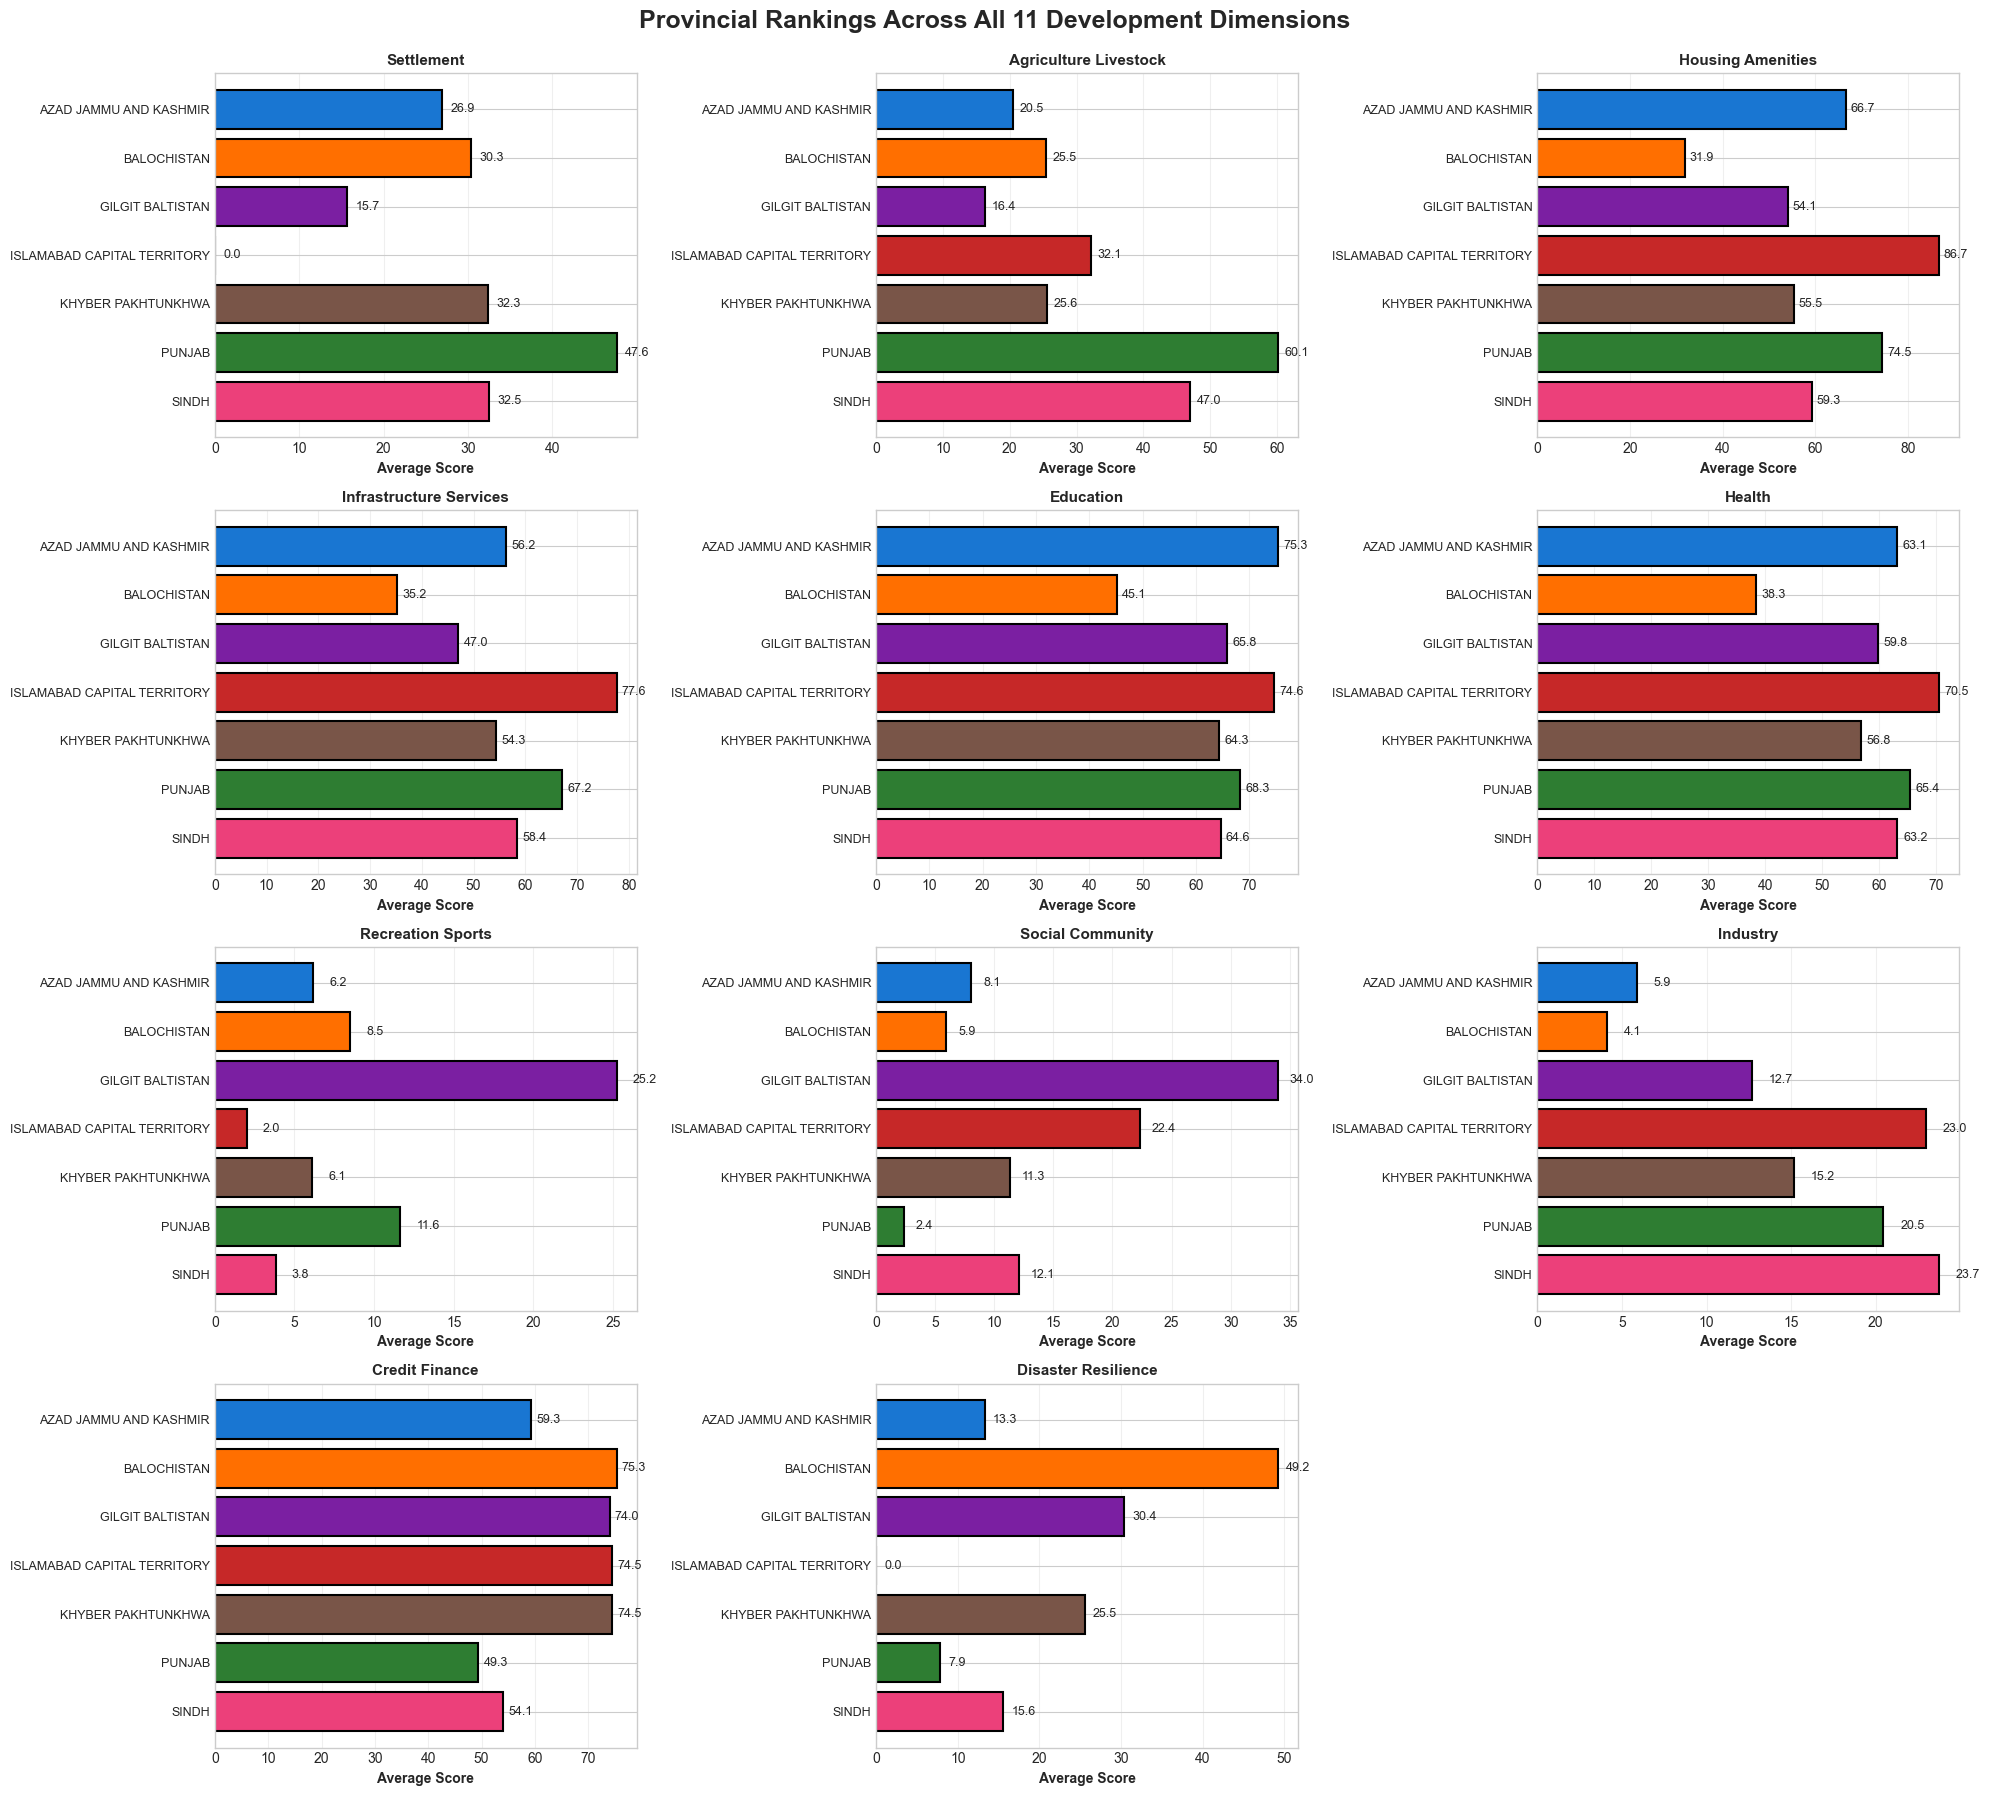


💡 KEY INSIGHT: Rankings vary by dimension - no province dominates everything.
   Each province has specific areas where it excels or struggles.


In [ ]:
# Create individual bar charts for each dimension
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(index_cols):
    dimension_name = col.replace('_Index', '').replace('_', ' ')
    province_scores = df.groupby('Name of Province')[col].mean().reindex(province_order)
    
    # Use consistent province colors
    colors = [province_colors[prov] for prov in province_scores.index]
    
    axes[idx].barh(range(len(province_scores)), province_scores.values, 
                   color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_yticks(range(len(province_scores)))
    axes[idx].set_yticklabels(province_scores.index, fontsize=9)
    axes[idx].set_xlabel('Average Score', fontweight='bold', fontsize=10)
    axes[idx].set_title(dimension_name, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(province_scores.values):
        axes[idx].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

# Hide the last subplot if needed
if len(index_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Provincial Rankings Across All 11 Development Dimensions', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: Rankings vary by dimension - no province dominates everything.")
print("   Each province has specific areas where it excels or struggles.")

## Q4: How much variation exists within each dimension?

Let's see the distribution of district scores for each dimension using box plots.

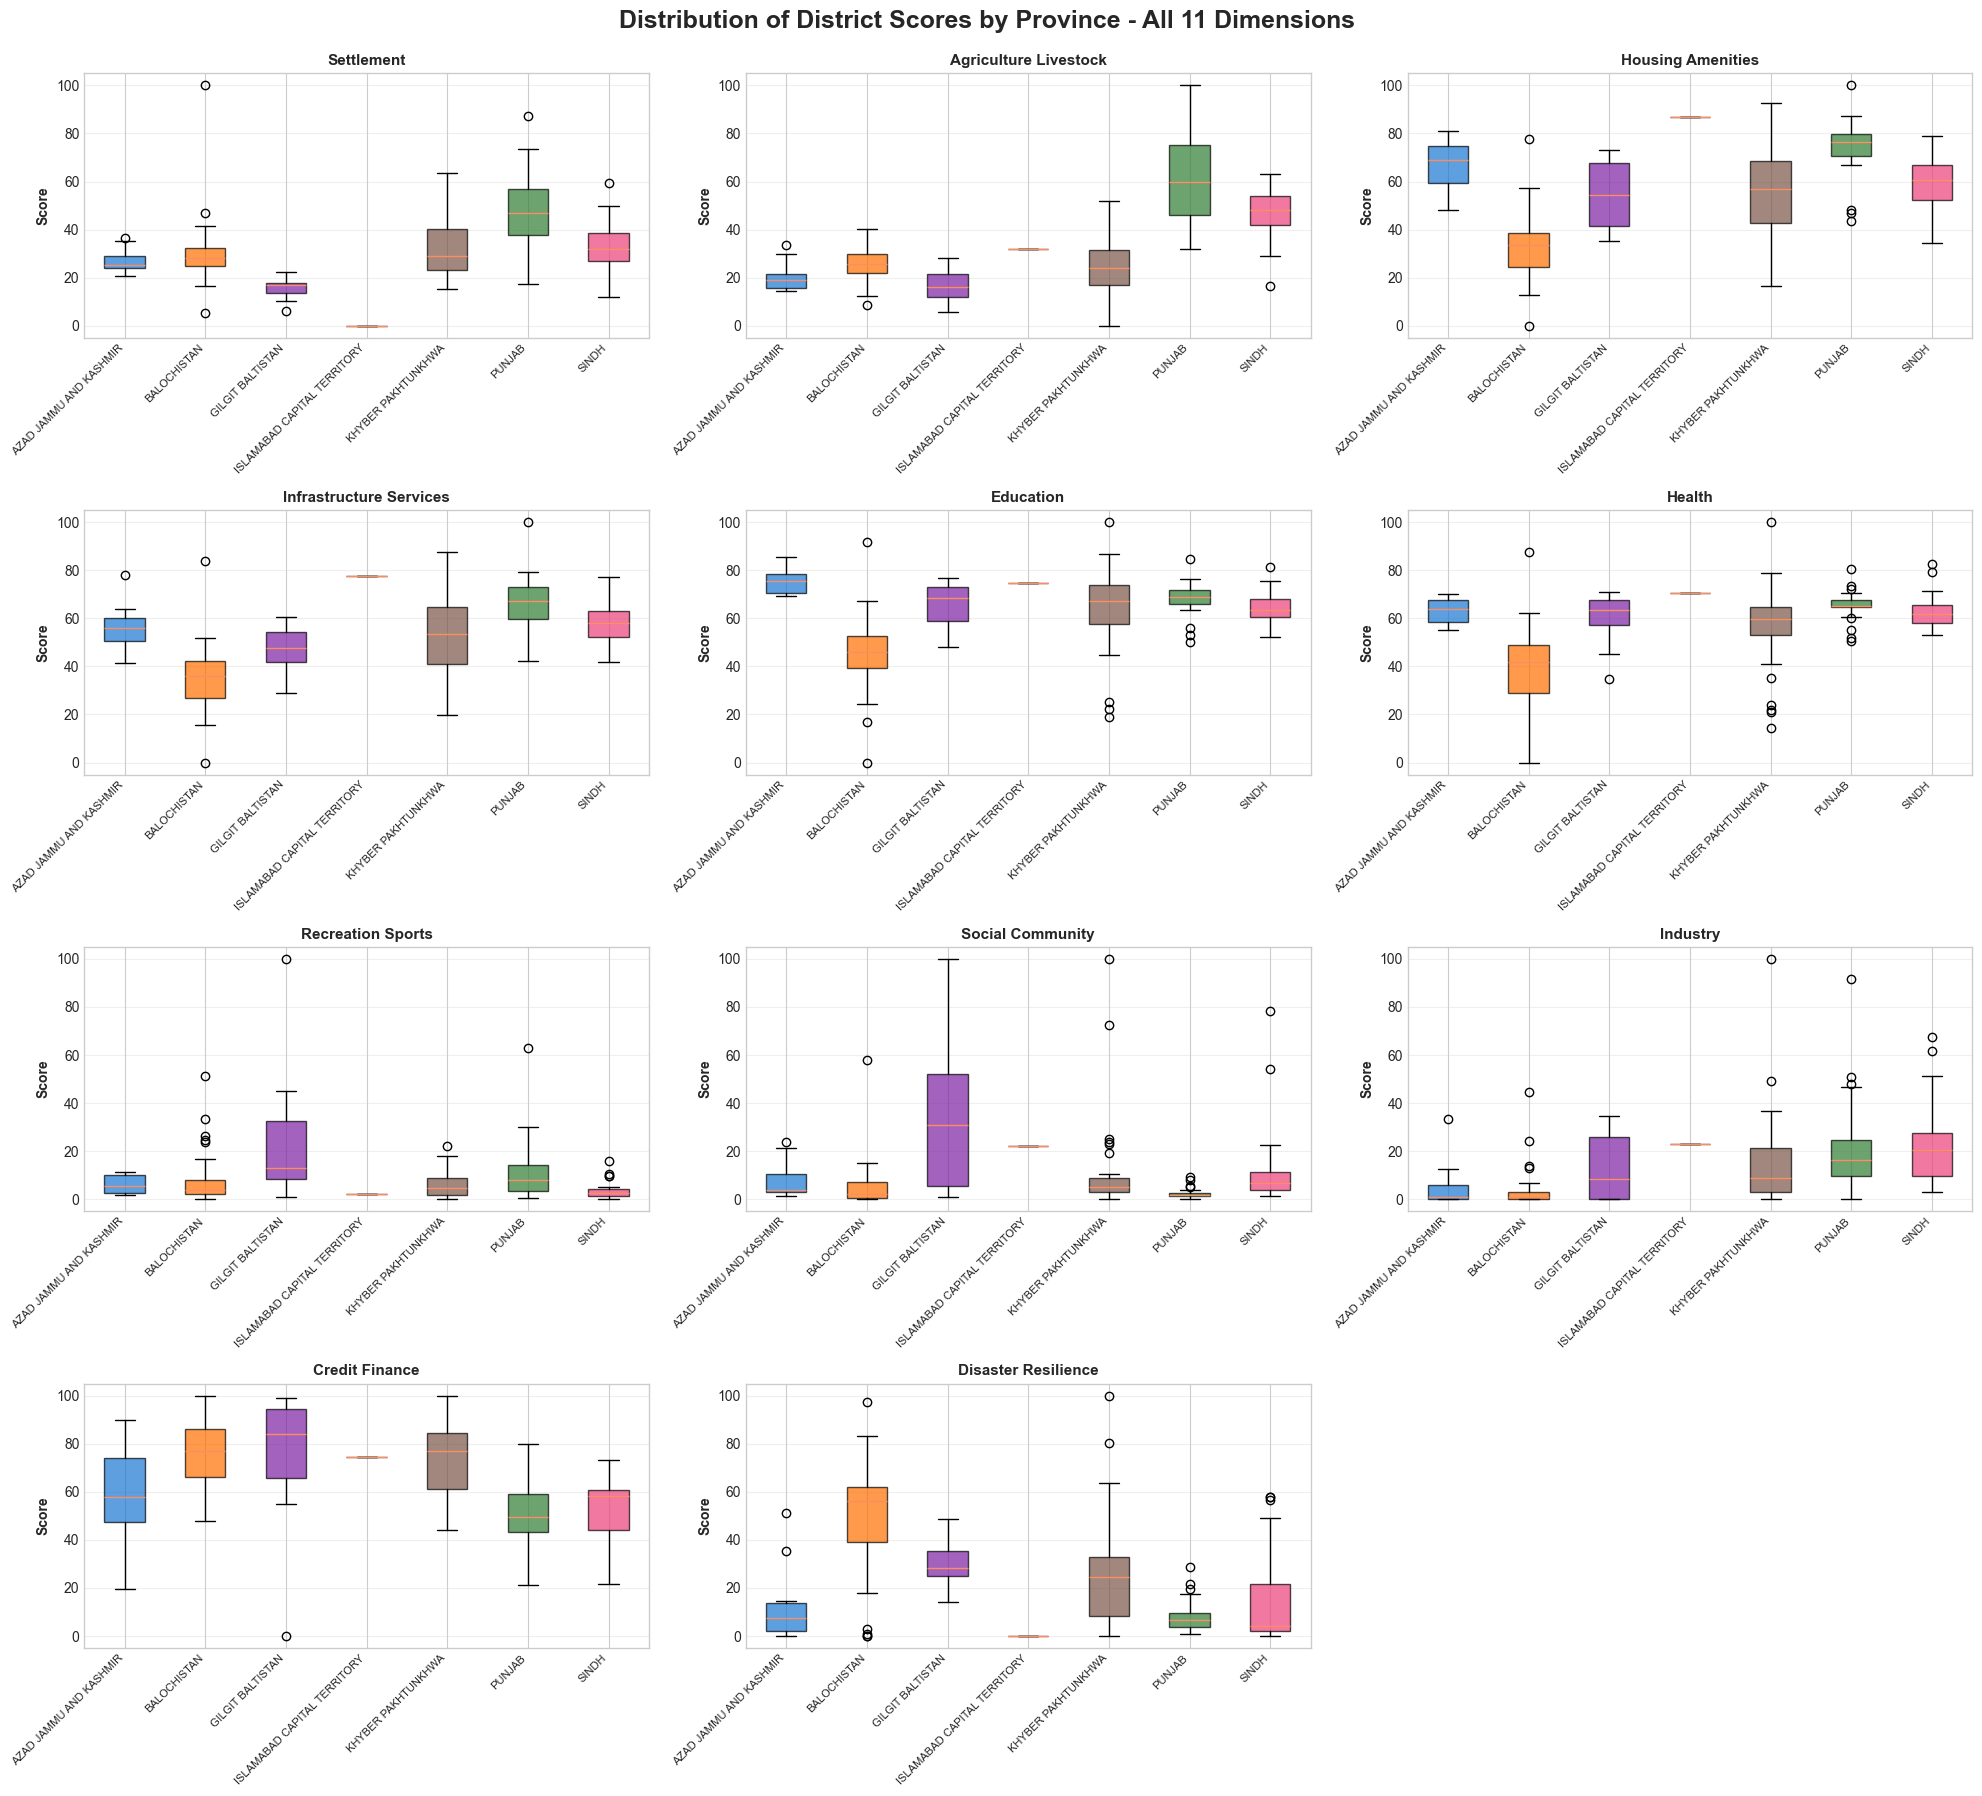


💡 KEY INSIGHT: Box plots show not just averages but the full range.
   Some provinces have wide variation (inconsistent districts), others are more uniform.


In [ ]:
# Box plots for all 11 dimensions
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.ravel()

for idx, col in enumerate(index_cols):
    dimension_name = col.replace('_Index', '').replace('_', ' ')
    
    # Prepare data by province with consistent ordering
    province_data = []
    for prov in province_order:
        province_data.append(df[df['Name of Province'] == prov][col].values)
    
    bp = axes[idx].boxplot(province_data, labels=province_order, patch_artist=True)
    
    # Color boxes with consistent province colors
    for patch, prov in zip(bp['boxes'], province_order):
        patch.set_facecolor(province_colors[prov])
        patch.set_alpha(0.7)
    
    axes[idx].set_xticklabels(province_order, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Score', fontweight='bold', fontsize=10)
    axes[idx].set_title(dimension_name, fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide the last subplot if needed
if len(index_cols) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribution of District Scores by Province - All 11 Dimensions', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT: Box plots show not just averages but the full range.")
print("   Some provinces have wide variation (inconsistent districts), others are more uniform.")

## Q5: Which dimensions show the biggest gaps between best and worst districts?

Understanding where inequality is highest helps prioritize interventions.

---
# 🏆 PART 3: Overall Performance - Champions & Strugglers

Now that we understand individual dimensions, let's look at overall development (average across all 11 dimensions).

## Q6: Which are the top performing districts overall?


🏆 TOP 20 DISTRICTS - PAKISTAN'S DEVELOPMENT CHAMPIONS

  17. MALAKAND PROTECTED AREA        (KHYBER PAKHTUNKHWA  ) - Score: 58.5
  145. LAHORE DISTRICT                (PUNJAB              ) - Score: 56.7
  130. HUNZA DISTRICT                 (GILGIT BALTISTAN    ) - Score: 54.1
  35. FAISALABAD DISTRICT            (PUNJAB              ) - Score: 53.0
  15. CHITRAL UPPER                  (KHYBER PAKHTUNKHWA  ) - Score: 51.7
  143. MALIR DISTRICT                 (SINDH               ) - Score: 51.4
  37. TOBA TEK SINGH DISTRICT        (PUNJAB              ) - Score: 50.2
  21. MARDAN DISTRICT                (KHYBER PAKHTUNKHWA  ) - Score: 48.9
  49. MULTAN DISTRICT                (PUNJAB              ) - Score: 48.7
  128. GHIZER DISTRICT                (GILGIT BALTISTAN    ) - Score: 47.9
  43. SIALKOT DISTRICT               (PUNJAB              ) - Score: 47.7
  61. SARGODHA DISTRICT              (PUNJAB              ) - Score: 47.6
  38. GUJRANWALA DISTRICT            (PUNJAB        

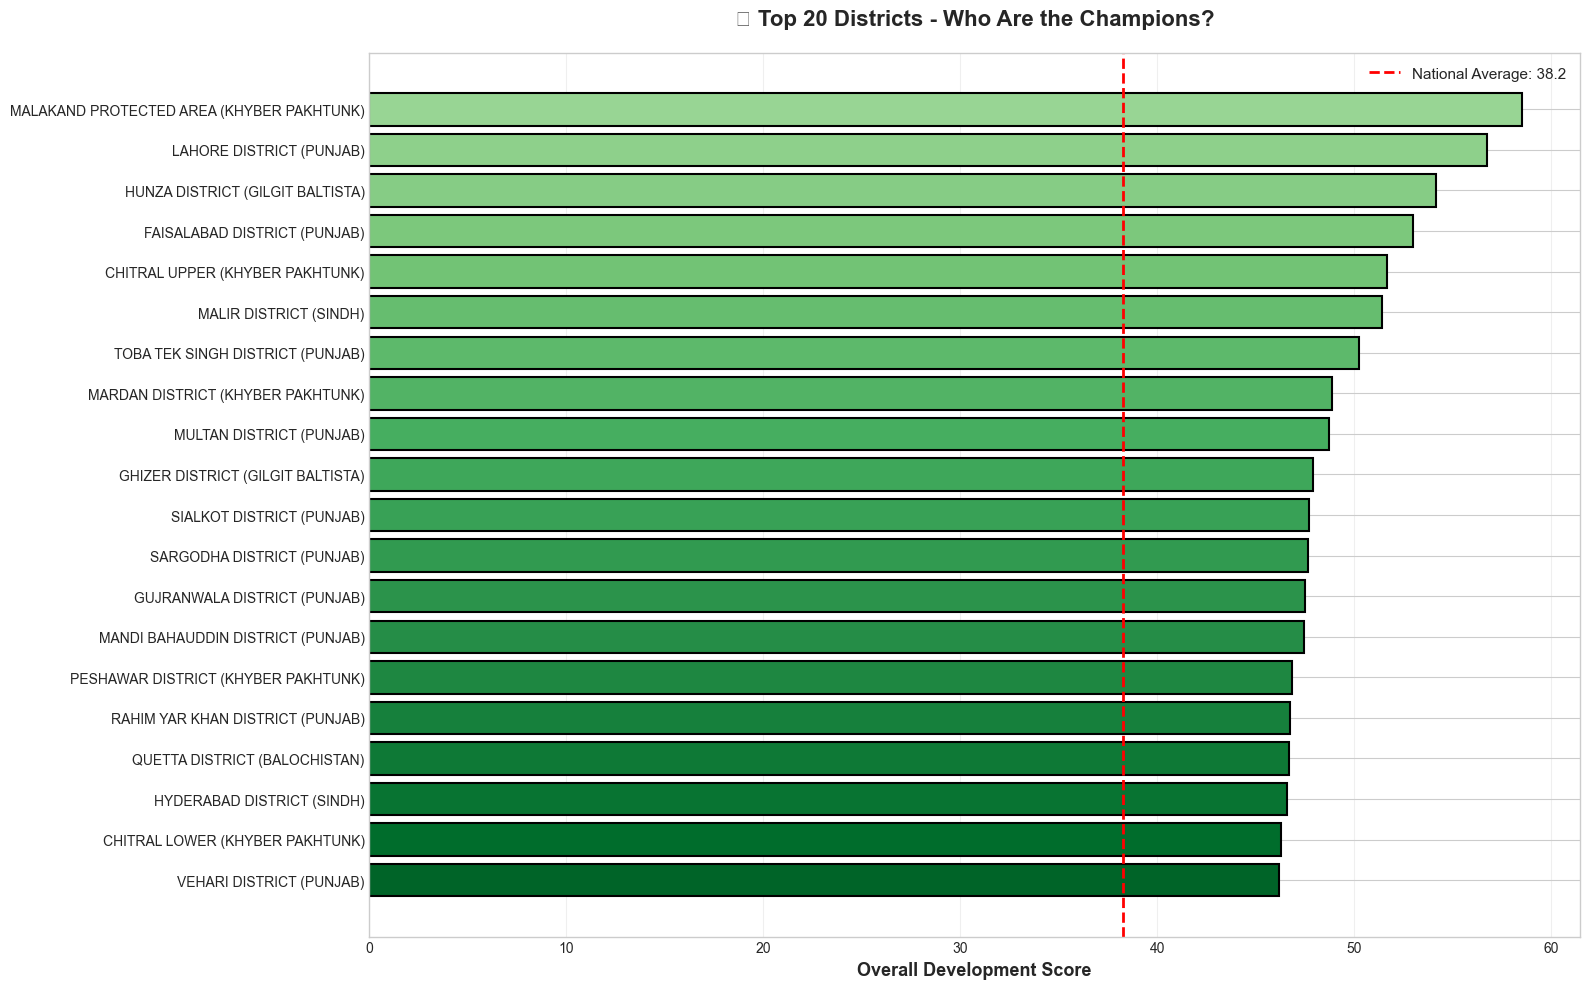


💡 KEY INSIGHT: The best district (MALAKAND PROTECTED AREA) scores 58.5,
   which is 20.3 points above the national average.


In [ ]:
# Top 20 performing districts
top_20 = df.nlargest(20, 'Composite_Score')[['Name of District', 'Name of Province', 'Name of Division', 'Composite_Score']]

print("\n" + "="*90)
print("🏆 TOP 20 DISTRICTS - PAKISTAN'S DEVELOPMENT CHAMPIONS")
print("="*90)
print()
for i, row in top_20.iterrows():
    print(f"  {row.name+1:2d}. {row['Name of District']:30s} ({row['Name of Province']:20s}) - Score: {row['Composite_Score']:.1f}")

# Visualization
plt.figure(figsize=(16, 10))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_20)))
plt.barh(range(len(top_20)), top_20['Composite_Score'], color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(top_20)), 
           [f"{row['Name of District'][:25]} ({row['Name of Province'][:15]})" 
            for _, row in top_20.iterrows()], fontsize=10)
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.title('🏆 Top 20 Districts - Who Are the Champions?', fontweight='bold', fontsize=16, pad=20)
plt.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Average: {df["Composite_Score"].mean():.1f}')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The best district ({top_20.iloc[0]['Name of District']}) scores {top_20.iloc[0]['Composite_Score']:.1f},")
print(f"   which is {top_20.iloc[0]['Composite_Score'] - df['Composite_Score'].mean():.1f} points above the national average.")

## Q2: What about the districts that need the most support?


⚠️  BOTTOM 20 DISTRICTS - WHERE SUPPORT IS MOST NEEDED

  106. KOHLU DISTRICT                 (BALOCHISTAN         ) - Score: 19.1
  151. KOLAI PALAS KOHISTAN           (KHYBER PAKHTUNKHWA  ) - Score: 22.4
  149. KOHISTAN DISTRICT              (KHYBER PAKHTUNKHWA  ) - Score: 24.1
  115. ZHOB DISTRICT                  (BALOCHISTAN         ) - Score: 25.3
  84. AWARAN DISTRICT                (BALOCHISTAN         ) - Score: 25.8
  112. DUKI DISTRICT                  (BALOCHISTAN         ) - Score: 26.0
  91. WASHUK DISTRICT                (BALOCHISTAN         ) - Score: 26.2
  88. KHUZDAR DISTRICT               (BALOCHISTAN         ) - Score: 26.5
  92. GWADAR DISTRICT                (BALOCHISTAN         ) - Score: 26.5
  113. MUSAKHEL DISTRICT              (BALOCHISTAN         ) - Score: 26.9
  85. KALAT DISTRICT                 (BALOCHISTAN         ) - Score: 27.0
  114. SHERANI DISTRICT               (BALOCHISTAN         ) - Score: 27.8
  150. LOWER KOHISTAN                 (KHYBER PA

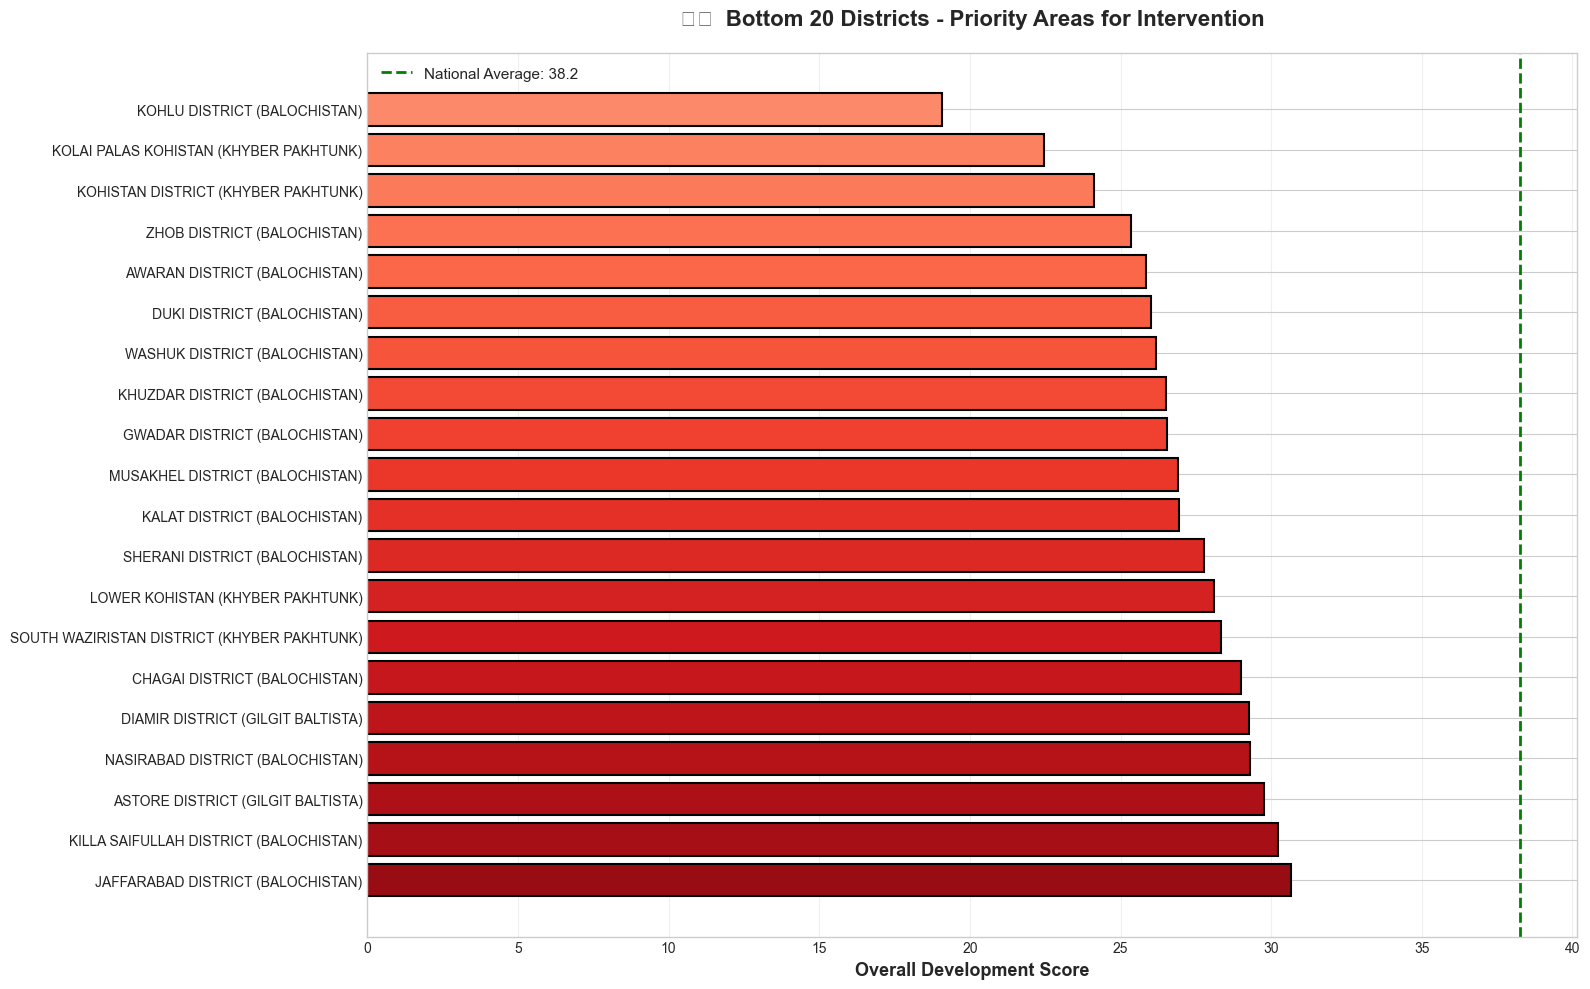


💡 KEY INSIGHT: There's a 39.4 point gap between the best and worst performing districts.
   This represents significant inequality in development across Pakistan.


In [ ]:
# Bottom 20 districts
bottom_20 = df.nsmallest(20, 'Composite_Score')[['Name of District', 'Name of Province', 'Name of Division', 'Composite_Score']]

print("\n" + "="*90)
print("⚠️  BOTTOM 20 DISTRICTS - WHERE SUPPORT IS MOST NEEDED")
print("="*90)
print()
for i, row in bottom_20.iterrows():
    print(f"  {row.name+1:2d}. {row['Name of District']:30s} ({row['Name of Province']:20s}) - Score: {row['Composite_Score']:.1f}")

# Visualization
plt.figure(figsize=(16, 10))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(bottom_20)))
plt.barh(range(len(bottom_20)), bottom_20['Composite_Score'], color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(bottom_20)), 
           [f"{row['Name of District'][:25]} ({row['Name of Province'][:15]})" 
            for _, row in bottom_20.iterrows()], fontsize=10)
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.title('⚠️  Bottom 20 Districts - Priority Areas for Intervention', fontweight='bold', fontsize=16, pad=20)
plt.axvline(df['Composite_Score'].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'National Average: {df["Composite_Score"].mean():.1f}')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

gap = top_20.iloc[0]['Composite_Score'] - bottom_20.iloc[0]['Composite_Score']
print(f"\n💡 KEY INSIGHT: There's a {gap:.1f} point gap between the best and worst performing districts.")
print(f"   This represents significant inequality in development across Pakistan.")

## Q3: How are all 153 districts distributed across the development spectrum?

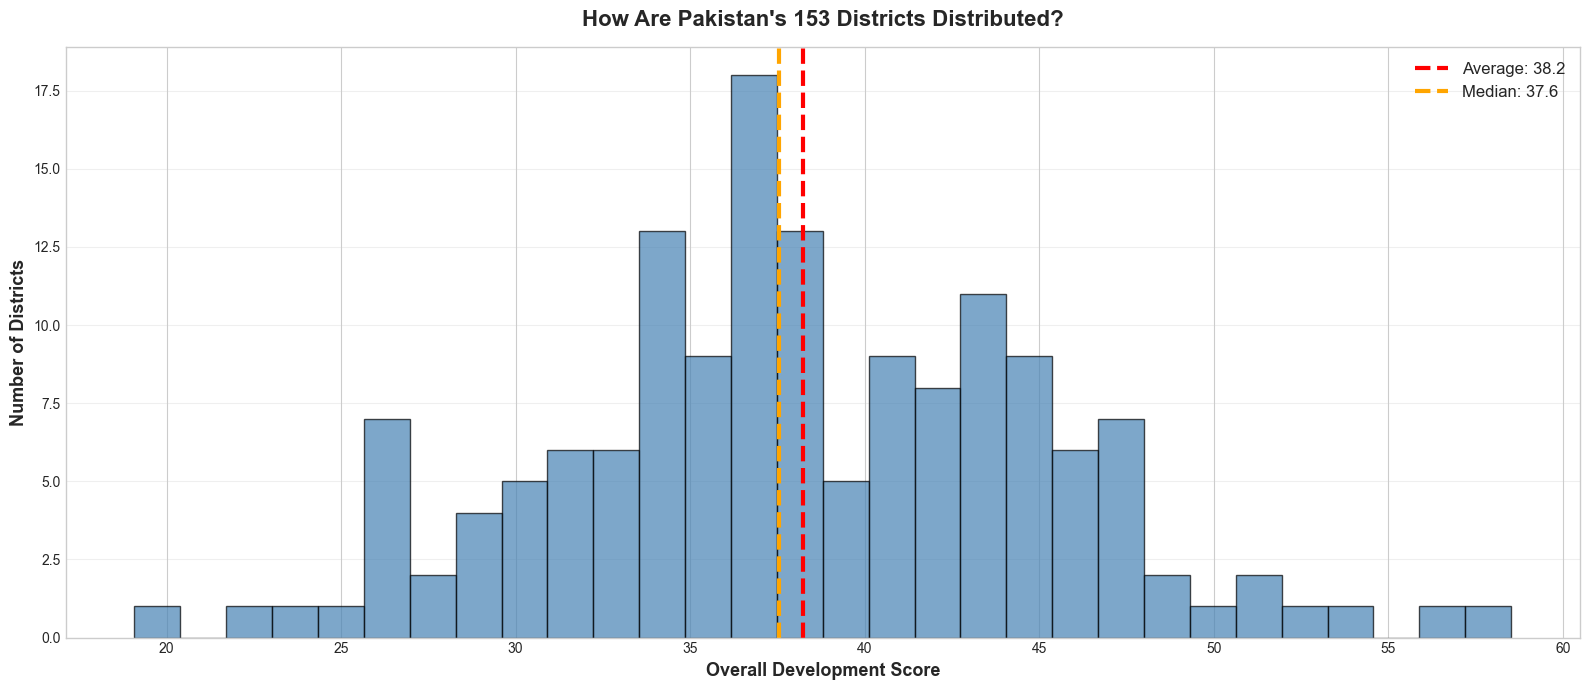


📊 DISTRICT DISTRIBUTION:
   • 127 districts (84.1%) score below 45 (Low development)
   • 22 districts (14.6%) score 45-55 (Medium development)
   • 2 districts (1.3%) score above 55 (High development)


In [ ]:
# Overall distribution
plt.figure(figsize=(16, 7))
plt.hist(df['Composite_Score'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=3, 
            label=f'Average: {df["Composite_Score"].mean():.1f}')
plt.axvline(df['Composite_Score'].median(), color='orange', linestyle='--', linewidth=3, 
            label=f'Median: {df["Composite_Score"].median():.1f}')
plt.xlabel('Overall Development Score', fontweight='bold', fontsize=13)
plt.ylabel('Number of Districts', fontweight='bold', fontsize=13)
plt.title('How Are Pakistan\'s 153 Districts Distributed?', fontweight='bold', fontsize=16, pad=15)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Count districts in different ranges
low = len(df[df['Composite_Score'] < 45])
medium = len(df[(df['Composite_Score'] >= 45) & (df['Composite_Score'] < 55)])
high = len(df[df['Composite_Score'] >= 55])

print(f"\n📊 DISTRICT DISTRIBUTION:")
print(f"   • {low} districts ({low/len(df)*100:.1f}%) score below 45 (Low development)")
print(f"   • {medium} districts ({medium/len(df)*100:.1f}%) score 45-55 (Medium development)")
print(f"   • {high} districts ({high/len(df)*100:.1f}%) score above 55 (High development)")

---
# 🎯 PART 3: What Drives Success?

Now that we know who's doing well, let's understand WHY by looking at which development areas matter most.

## Q4: Which development dimensions are most important for overall success?


🎯 WHICH DEVELOPMENT AREAS MATTER MOST?

Importance Ranking (using machine learning analysis):

   3. Housing Amenities                   ██████████████████████ 0.225
   4. Infrastructure Services             █████████████████ 0.173
   6. Health                              ████████████████ 0.168
   9. Industry                            ███████████████ 0.159
   5. Education                           ████████ 0.081
   7. Recreation Sports                   ███████ 0.070
   8. Social Community                    ███ 0.039
  11. Disaster Resilience                 ██ 0.027
   1. Settlement                          ██ 0.021
   2. Agriculture Livestock               █ 0.020
  10. Credit Finance                      █ 0.017


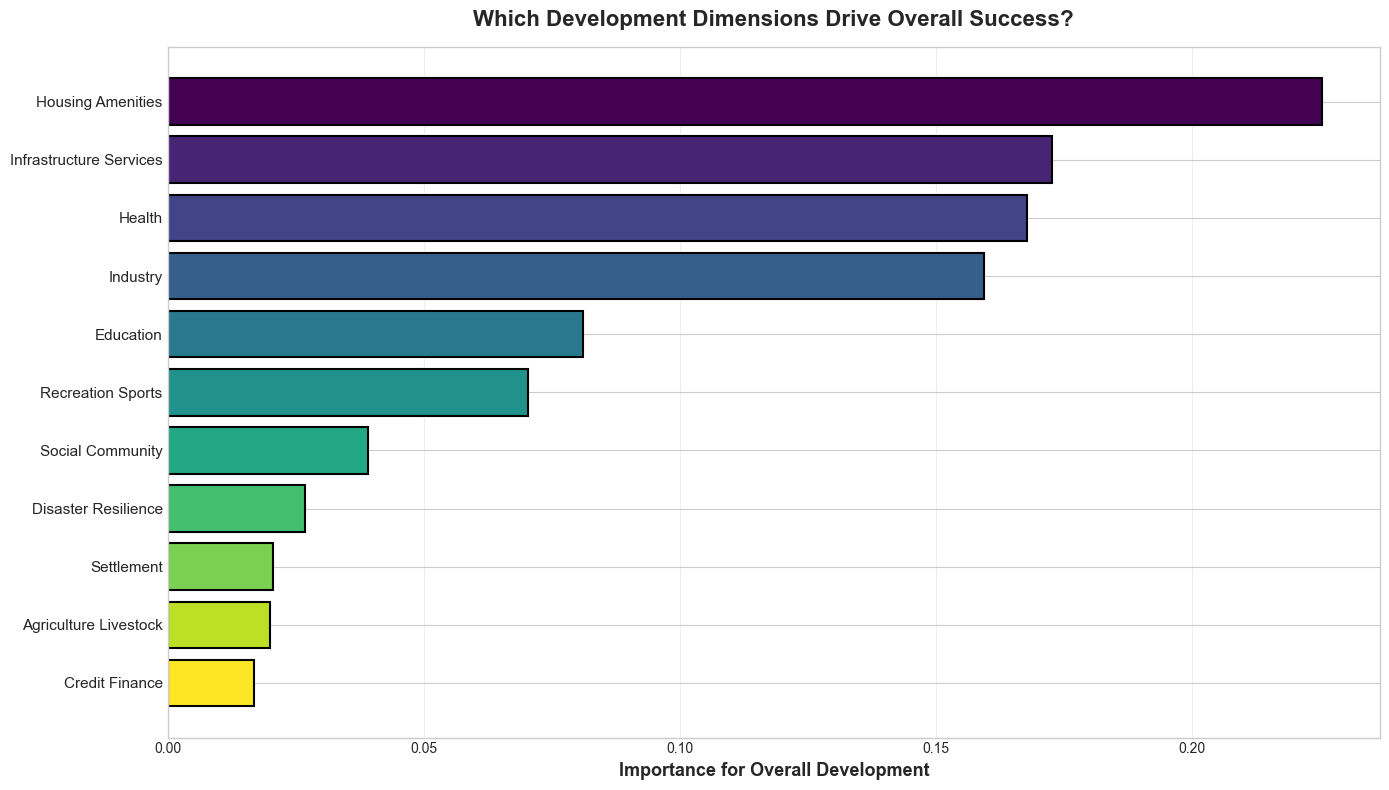


💡 KEY INSIGHT: The top 3 drivers of overall development are:
   3. Housing Amenities
   4. Infrastructure Services
   6. Health
   Focus on these areas can have the biggest impact on overall development.


In [ ]:
# Use Random Forest to identify which dimensions drive overall development
X = df[index_cols]
y = df['Composite_Score']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Dimension': [col.replace('_Index', '').replace('_', ' ') for col in index_cols],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*90)
print("🎯 WHICH DEVELOPMENT AREAS MATTER MOST?")
print("="*90)
print("\nImportance Ranking (using machine learning analysis):\n")
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {i+1:2d}. {row['Dimension']:35s} {bar} {row['Importance']:.3f}")

# Visualization
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
plt.barh(range(len(importance_df)), importance_df['Importance'], 
         color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(importance_df)), importance_df['Dimension'], fontsize=11)
plt.xlabel('Importance for Overall Development', fontweight='bold', fontsize=13)
plt.title('Which Development Dimensions Drive Overall Success?', fontweight='bold', fontsize=16, pad=15)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The top 3 drivers of overall development are:")
for i, row in importance_df.head(3).iterrows():
    print(f"   {i+1}. {row['Dimension']}")
print("   Focus on these areas can have the biggest impact on overall development.")

## Q5: How do top performers compare to bottom performers across these dimensions?


TOP 10 vs BOTTOM 10 DISTRICTS - WHERE ARE THE BIGGEST GAPS?



,Dimension,Top 10 Avg,Bottom 10 Avg,Gap
2,Housing Amenities,76.00,19.00,57.00
4,Education,77.00,27.30,49.60
3,Infrastructure Services,71.80,22.40,49.40
5,Health,72.20,23.90,48.20
8,Industry,46.90,1.70,45.20
7,Social Community,36.50,3.40,33.00
6,Recreation Sports,32.90,3.10,29.80
1,Agriculture Livestock,48.10,19.00,29.10
0,Settlement,28.00,37.70,-9.70
9,Credit Finance,62.00,75.50,-13.40


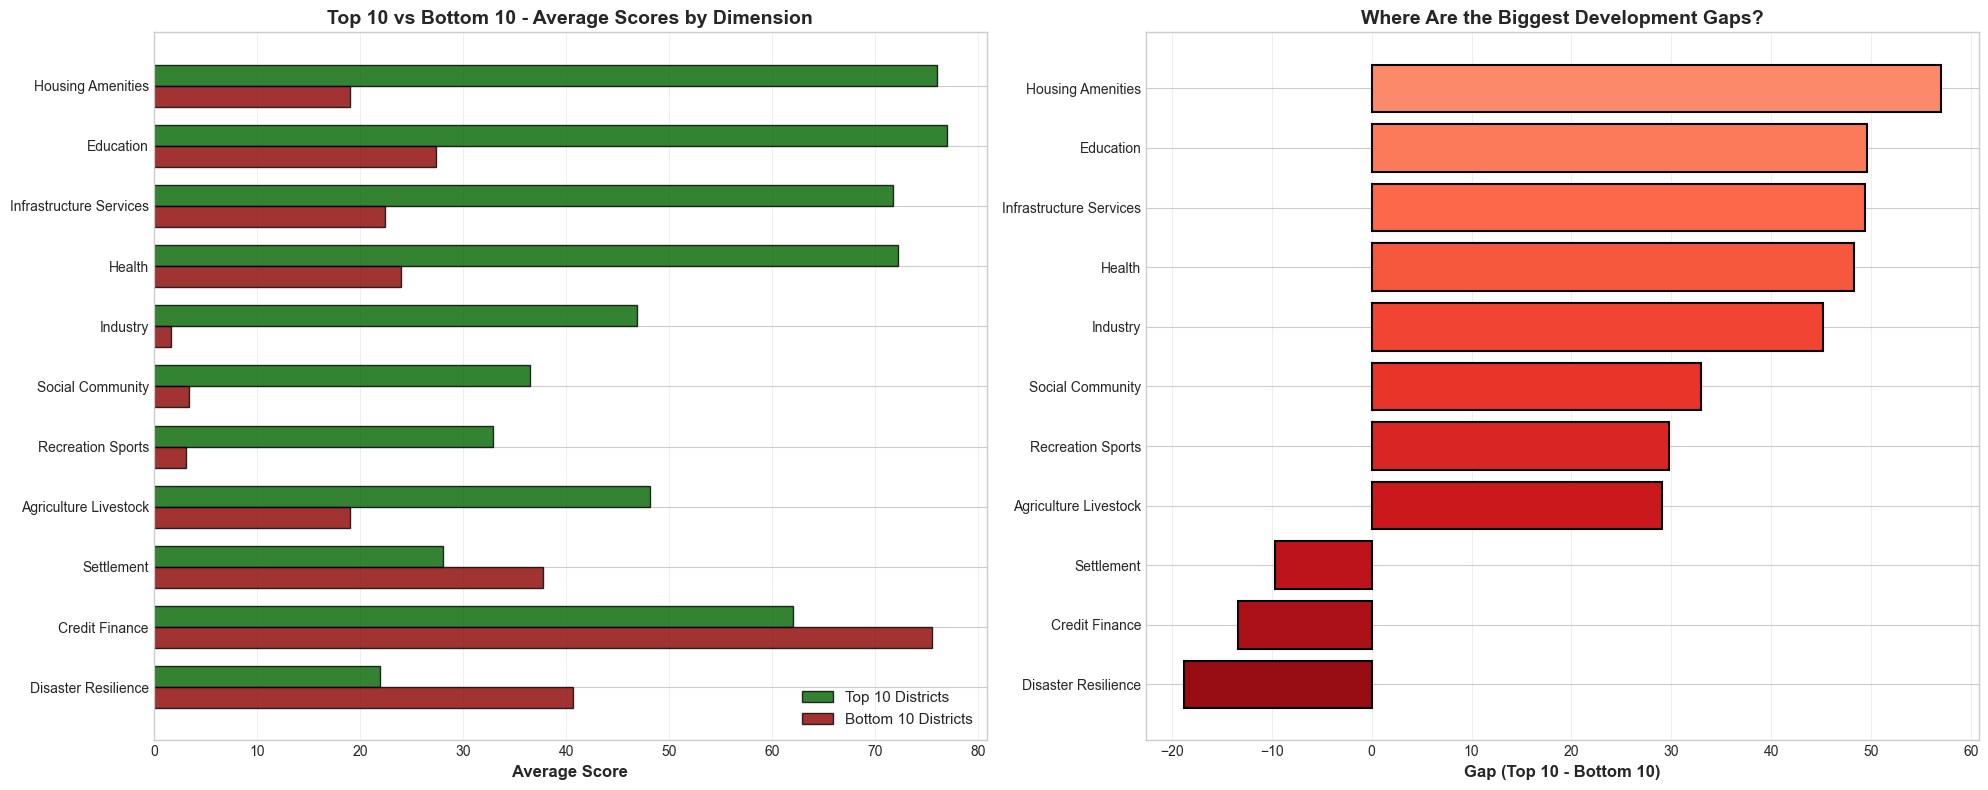


💡 KEY INSIGHT: The biggest gap is in Housing Amenities (57.0 points)
   This is where top and bottom performers differ most dramatically.


In [ ]:
# Compare top 10 vs bottom 10
top_10_avg = df.nlargest(10, 'Composite_Score')[index_cols].mean()
bottom_10_avg = df.nsmallest(10, 'Composite_Score')[index_cols].mean()
difference = top_10_avg - bottom_10_avg

comparison_df = pd.DataFrame({
    'Dimension': [col.replace('_Index', '').replace('_', ' ') for col in index_cols],
    'Top 10 Avg': top_10_avg.values,
    'Bottom 10 Avg': bottom_10_avg.values,
    'Gap': difference.values
}).sort_values('Gap', ascending=False)

print("\n" + "="*90)
print("TOP 10 vs BOTTOM 10 DISTRICTS - WHERE ARE THE BIGGEST GAPS?")
print("="*90)
print()
display(comparison_df.round(1))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

x = np.arange(len(comparison_df))
width = 0.35

ax1.barh(x - width/2, comparison_df['Top 10 Avg'], width, label='Top 10 Districts', 
         color='darkgreen', alpha=0.8, edgecolor='black')
ax1.barh(x + width/2, comparison_df['Bottom 10 Avg'], width, label='Bottom 10 Districts', 
         color='darkred', alpha=0.8, edgecolor='black')
ax1.set_yticks(x)
ax1.set_yticklabels(comparison_df['Dimension'], fontsize=10)
ax1.set_xlabel('Average Score', fontweight='bold', fontsize=12)
ax1.set_title('Top 10 vs Bottom 10 - Average Scores by Dimension', fontweight='bold', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Gap visualization
colors_gap = plt.cm.Reds(np.linspace(0.4, 0.9, len(comparison_df)))
ax2.barh(range(len(comparison_df)), comparison_df['Gap'], color=colors_gap, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(comparison_df)))
ax2.set_yticklabels(comparison_df['Dimension'], fontsize=10)
ax2.set_xlabel('Gap (Top 10 - Bottom 10)', fontweight='bold', fontsize=12)
ax2.set_title('Where Are the Biggest Development Gaps?', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: The biggest gap is in {comparison_df.iloc[0]['Dimension']} ({comparison_df.iloc[0]['Gap']:.1f} points)")
print(f"   This is where top and bottom performers differ most dramatically.")

## Q6: Are different development areas related to each other?

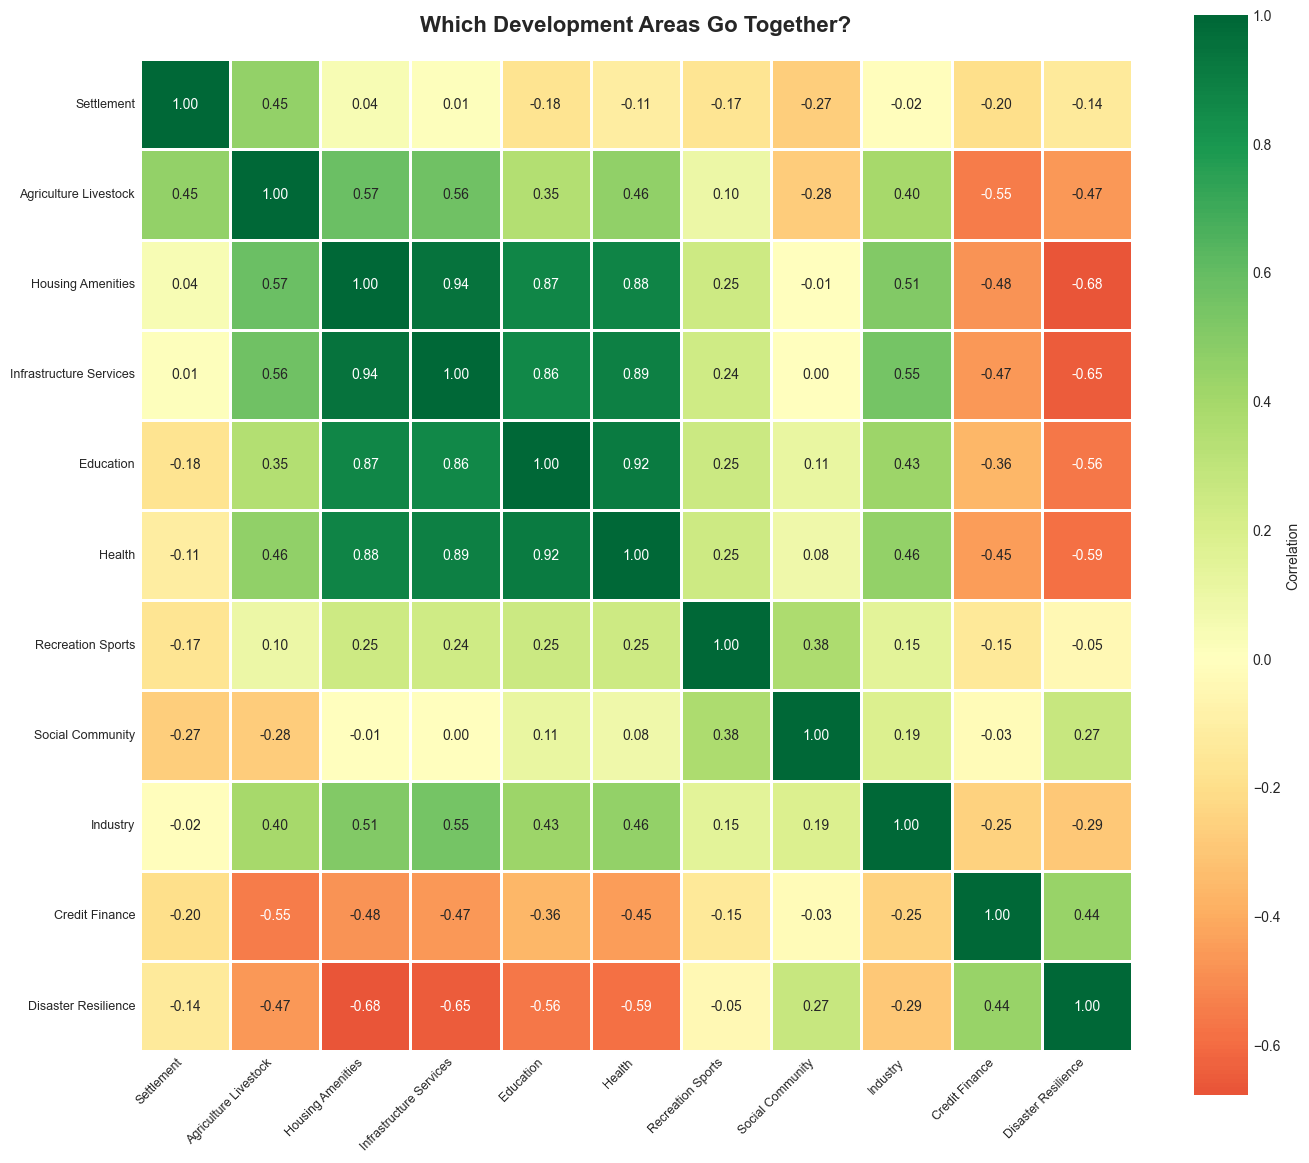


STRONGEST RELATIONSHIPS BETWEEN DEVELOPMENT AREAS

Top 5 pairs that tend to go together:

  1. Infrastructure Services ↔ Housing Amenities
     Correlation: 0.94 (Strong positive relationship)

  2. Health ↔ Education
     Correlation: 0.92 (Strong positive relationship)

  3. Health ↔ Infrastructure Services
     Correlation: 0.89 (Strong positive relationship)

  4. Health ↔ Housing Amenities
     Correlation: 0.88 (Strong positive relationship)

  5. Education ↔ Housing Amenities
     Correlation: 0.87 (Strong positive relationship)

💡 KEY INSIGHT: When districts score high in one area, they often score high in related areas.
   This suggests development in one sector can positively influence others.


In [ ]:
# Correlation analysis
corr_matrix = df[index_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, 
            xticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols],
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Which Development Areas Go Together?', fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Find strongest correlations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_no_diag = corr_matrix.mask(mask)
correlations = corr_no_diag.stack().sort_values(ascending=False)

print("\n" + "="*90)
print("STRONGEST RELATIONSHIPS BETWEEN DEVELOPMENT AREAS")
print("="*90)
print("\nTop 5 pairs that tend to go together:\n")
for i, (pair, corr) in enumerate(correlations.head(5).items(), 1):
    dim1 = pair[0].replace('_Index', '').replace('_', ' ')
    dim2 = pair[1].replace('_Index', '').replace('_', ' ')
    print(f"  {i}. {dim1} ↔ {dim2}")
    print(f"     Correlation: {corr:.2f} (Strong positive relationship)")
    print()

print("💡 KEY INSIGHT: When districts score high in one area, they often score high in related areas.")
print("   This suggests development in one sector can positively influence others.")

---
# 🗺️ PART 4: Geographic Patterns

Let's explore if there are regional patterns - do some provinces or divisions consistently perform better?

## Q7: Which provinces are leading in development?


🗺️  PROVINCIAL DEVELOPMENT RANKINGS



,Average,Lowest District,Highest District,Number of Districts
Name of Province,,,,
PUNJAB,43.16,34.05,56.74,37
ISLAMABAD CAPITAL TERRITORY,42.13,42.13,42.13,1
GILGIT BALTISTAN,39.55,29.25,54.14,10
SINDH,39.48,33.65,51.39,25
KHYBER PAKHTUNKHWA,38.31,22.45,58.52,35
AZAD JAMMU AND KASHMIR,36.49,31.12,45.32,10
BALOCHISTAN,31.75,19.08,46.66,33


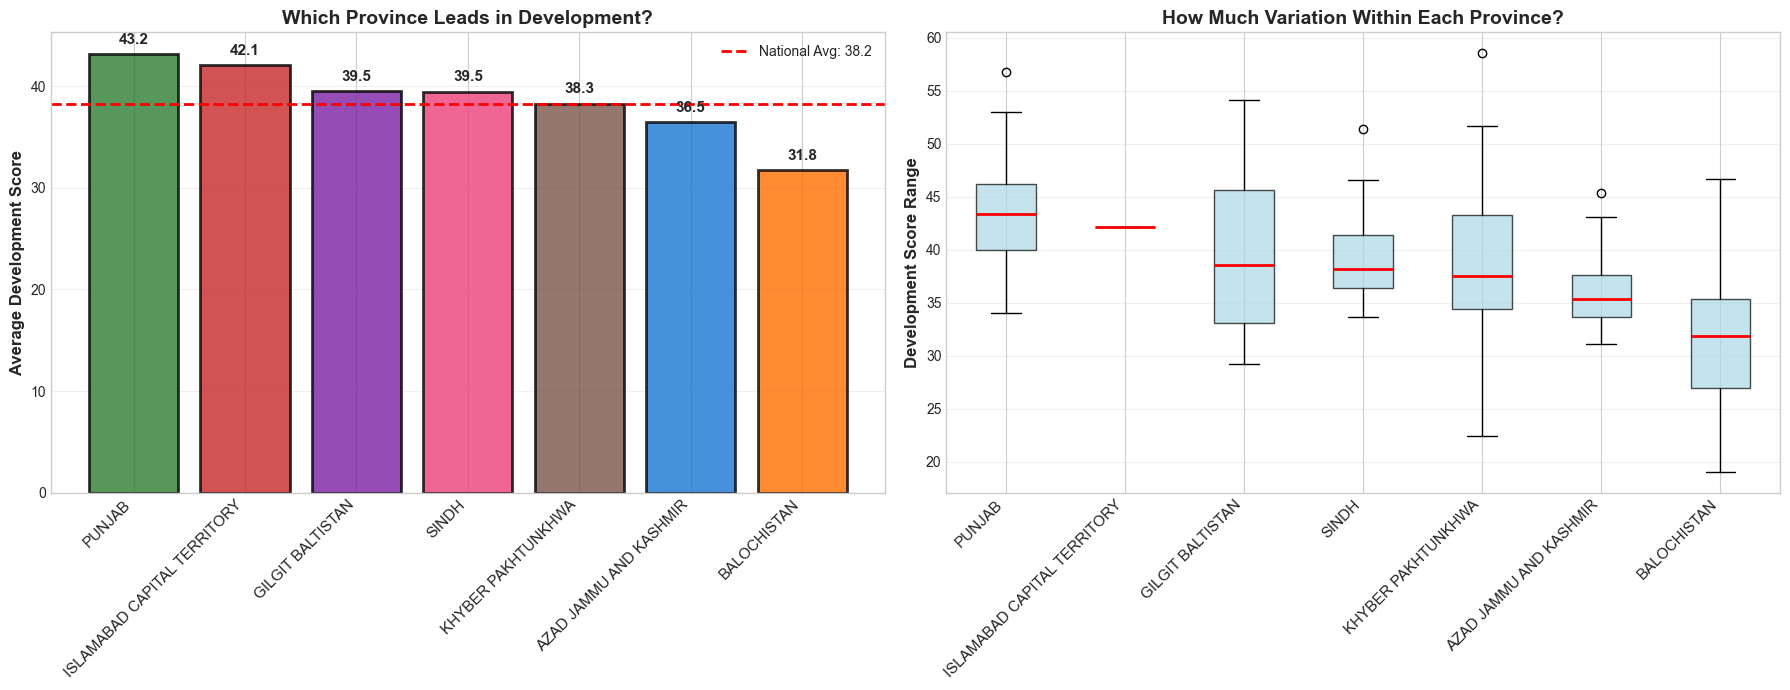


💡 KEY INSIGHTS:
   • PUNJAB leads with an average score of 43.2
   • BALOCHISTAN has the lowest average at 31.8
   • Provincial gap: 11.4 points
   • Note: Box plots show some provinces have more internal variation than others


In [ ]:
# Provincial analysis
province_stats = df.groupby('Name of Province').agg({
    'Composite_Score': ['mean', 'min', 'max', 'count']
}).round(2)
province_stats.columns = ['Average', 'Lowest District', 'Highest District', 'Number of Districts']
province_stats = province_stats.sort_values('Average', ascending=False)

print("\n" + "="*90)
print("🗺️  PROVINCIAL DEVELOPMENT RANKINGS")
print("="*90)
print()
display(province_stats)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Provincial averages - using consistent province colors
colors_prov = [PROVINCE_COLORS[prov] for prov in province_stats.index]
ax1.bar(range(len(province_stats)), province_stats['Average'], color=colors_prov, 
        edgecolor='black', linewidth=2, alpha=0.8)
ax1.set_xticks(range(len(province_stats)))
ax1.set_xticklabels(province_stats.index, rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Average Development Score', fontweight='bold', fontsize=12)
ax1.set_title('Which Province Leads in Development?', fontweight='bold', fontsize=14)
ax1.axhline(df['Composite_Score'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'National Avg: {df["Composite_Score"].mean():.1f}')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(province_stats['Average']):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)

# Box plot showing distribution within each province
province_data = [df[df['Name of Province'] == prov]['Composite_Score'].values 
                 for prov in province_stats.index]
bp = ax2.boxplot(province_data, labels=province_stats.index, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_xticklabels(province_stats.index, rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('Development Score Range', fontweight='bold', fontsize=12)
ax2.set_title('How Much Variation Within Each Province?', fontweight='bold', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_prov = province_stats.index[0]
worst_prov = province_stats.index[-1]
prov_gap = province_stats.iloc[0]['Average'] - province_stats.iloc[-1]['Average']

print(f"\n💡 KEY INSIGHTS:")
print(f"   • {best_prov} leads with an average score of {province_stats.iloc[0]['Average']:.1f}")
print(f"   • {worst_prov} has the lowest average at {province_stats.iloc[-1]['Average']:.1f}")
print(f"   • Provincial gap: {prov_gap:.1f} points")
print(f"   • Note: Box plots show some provinces have more internal variation than others")

## Q8: What about at the division level - are there regional clusters of development?


TOP 15 DIVISIONS - REGIONAL DEVELOPMENT LEADERS

   1. GILGIT DIVISION                (GILGIT BALTISTAN    ) - Score: 48.1
   2. MARDAN DIVISION                (KHYBER PAKHTUNKHWA  ) - Score: 46.5
   3. LAHORE DIVISION                (PUNJAB              ) - Score: 46.4
   4. KARACHI DIVISION               (SINDH               ) - Score: 46.1
   5. FAISALABAD DIVISION            (PUNJAB              ) - Score: 45.6
   6. MULTAN DIVISION                (PUNJAB              ) - Score: 45.2
   7. MALAKAND DIVISION              (KHYBER PAKHTUNKHWA  ) - Score: 45.0
   8. BAHAWALPUR DIVISION            (PUNJAB              ) - Score: 45.0
   9. GUJRANWALA DIVISION            (PUNJAB              ) - Score: 44.8
  10. SAHIWAL DIVISION               (PUNJAB              ) - Score: 43.8
  11. FEDERAL CAPITAL AREA           (ISLAMABAD CAPITAL TERRITORY) - Score: 42.1
  12. RAWALPINDI DIVISION            (PUNJAB              ) - Score: 41.7
  13. MIRPUR DIVISION                (AZAD JAMMU AND KA

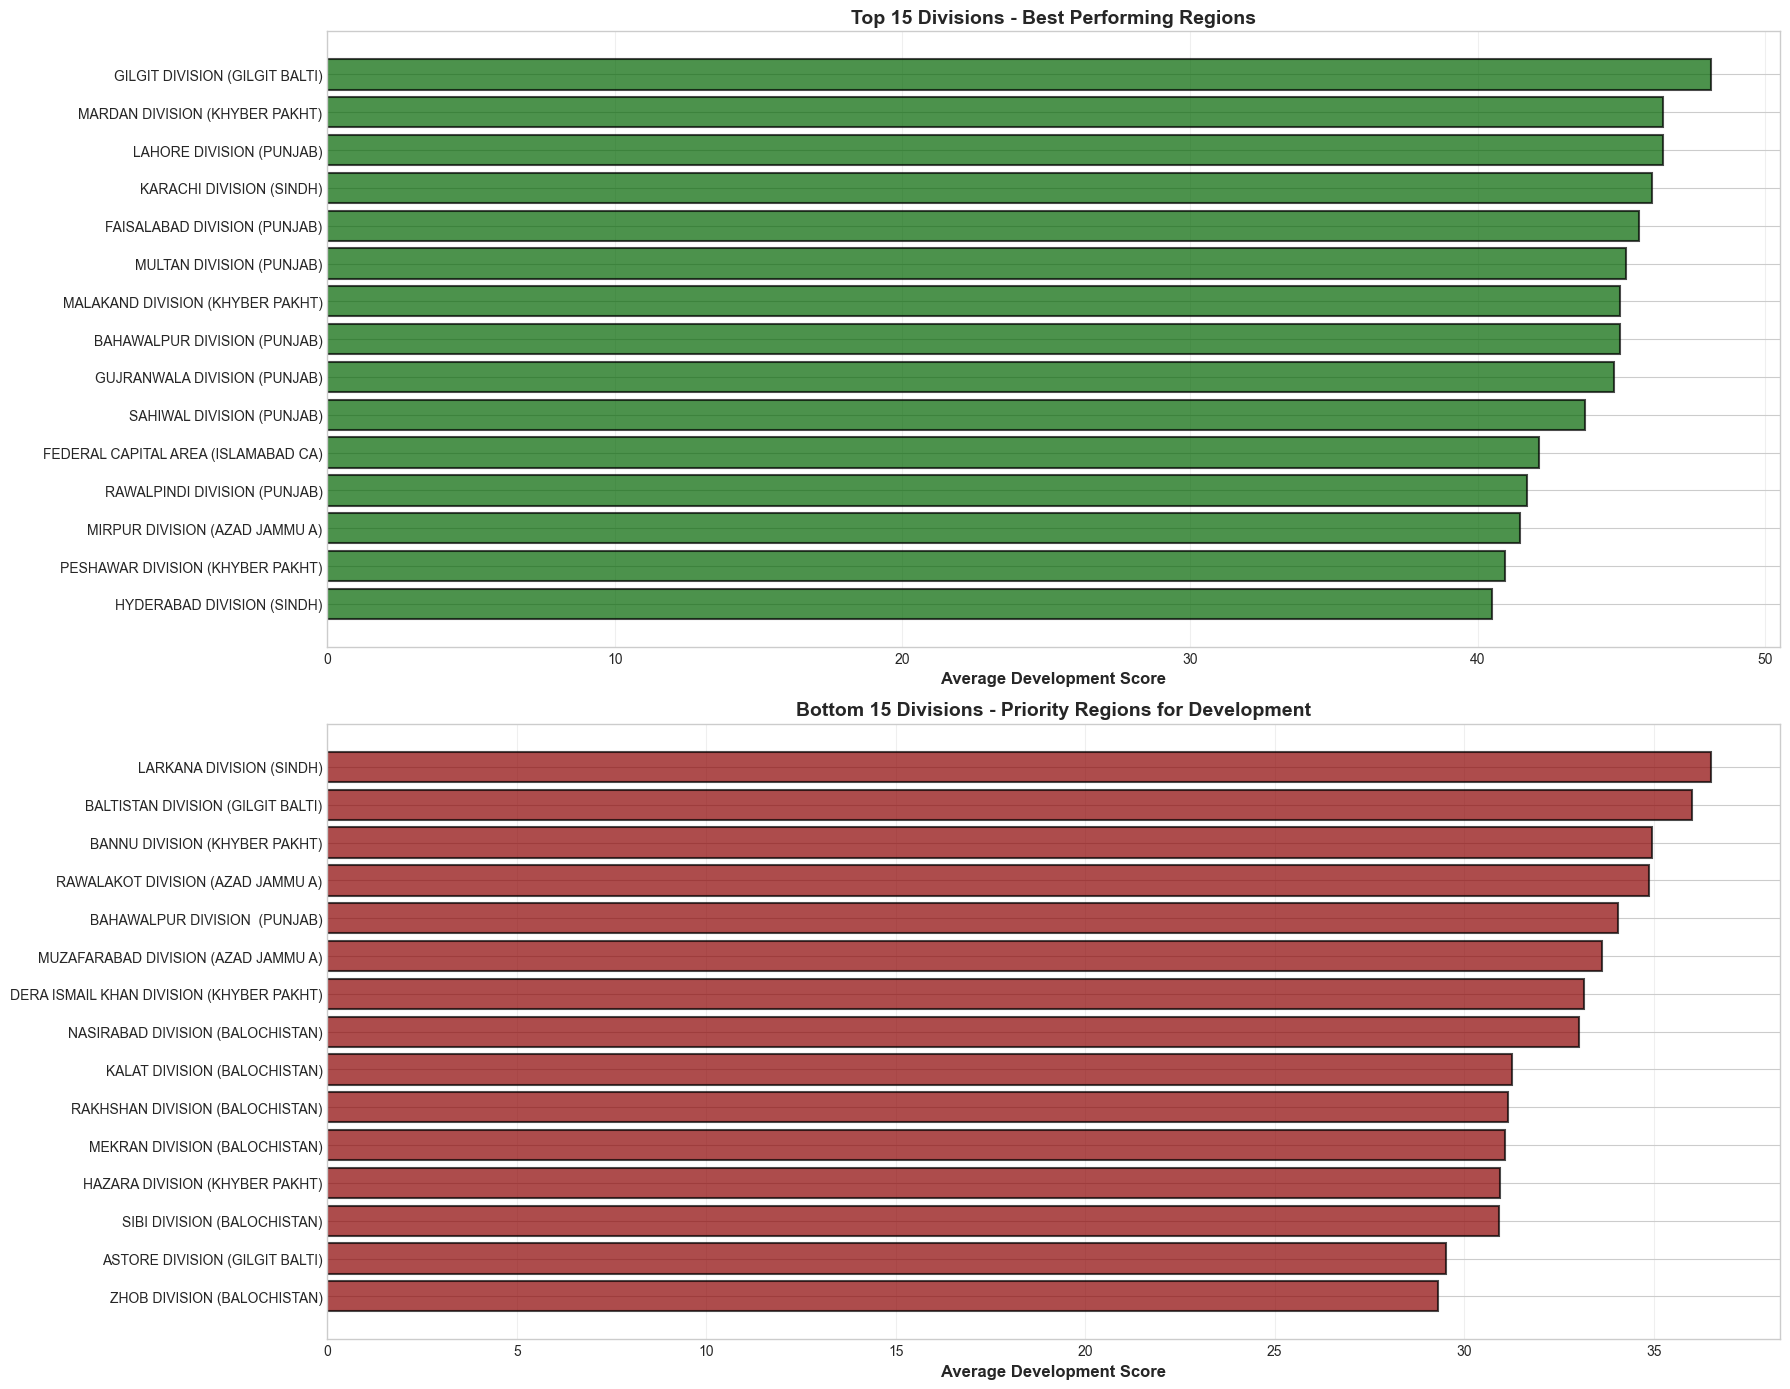


💡 KEY INSIGHT: Divisions within the same province can vary significantly.
   Development strategies may need to be targeted at division level, not just provincial.


In [ ]:
# Division analysis - top and bottom
division_scores = df.groupby(['Name of Division', 'Name of Province']).agg({
    'Composite_Score': ['mean', 'count']
}).round(2)
division_scores.columns = ['Average', 'Districts']
division_scores = division_scores.sort_values('Average', ascending=False).reset_index()

print("\n" + "="*90)
print("TOP 15 DIVISIONS - REGIONAL DEVELOPMENT LEADERS")
print("="*90)
print()
for i, row in division_scores.head(15).iterrows():
    print(f"  {i+1:2d}. {row['Name of Division']:30s} ({row['Name of Province']:20s}) - Score: {row['Average']:.1f}")

print("\n" + "="*90)
print("BOTTOM 15 DIVISIONS - REGIONS NEEDING MOST SUPPORT")
print("="*90)
print()
for i, row in division_scores.tail(15).iterrows():
    idx = len(division_scores) - 14 + (i - division_scores.tail(15).index[0])
    print(f"  {idx:2d}. {row['Name of Division']:30s} ({row['Name of Province']:20s}) - Score: {row['Average']:.1f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14))

# Top 15
top_15 = division_scores.head(15)
ax1.barh(range(len(top_15)), top_15['Average'], color='darkgreen', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels([f"{row['Name of Division'][:28]} ({row['Name of Province'][:12]})" 
                     for _, row in top_15.iterrows()], fontsize=10)
ax1.set_xlabel('Average Development Score', fontweight='bold', fontsize=12)
ax1.set_title('Top 15 Divisions - Best Performing Regions', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Bottom 15
bottom_15 = division_scores.tail(15)
ax2.barh(range(len(bottom_15)), bottom_15['Average'], color='darkred', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(bottom_15)))
ax2.set_yticklabels([f"{row['Name of Division'][:28]} ({row['Name of Province'][:12]})" 
                     for _, row in bottom_15.iterrows()], fontsize=10)
ax2.set_xlabel('Average Development Score', fontweight='bold', fontsize=12)
ax2.set_title('Bottom 15 Divisions - Priority Regions for Development', fontweight='bold', fontsize=14)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHT: Divisions within the same province can vary significantly.")
print(f"   Development strategies may need to be targeted at division level, not just provincial.")

## Q9: Do provinces have distinct development profiles across different dimensions?

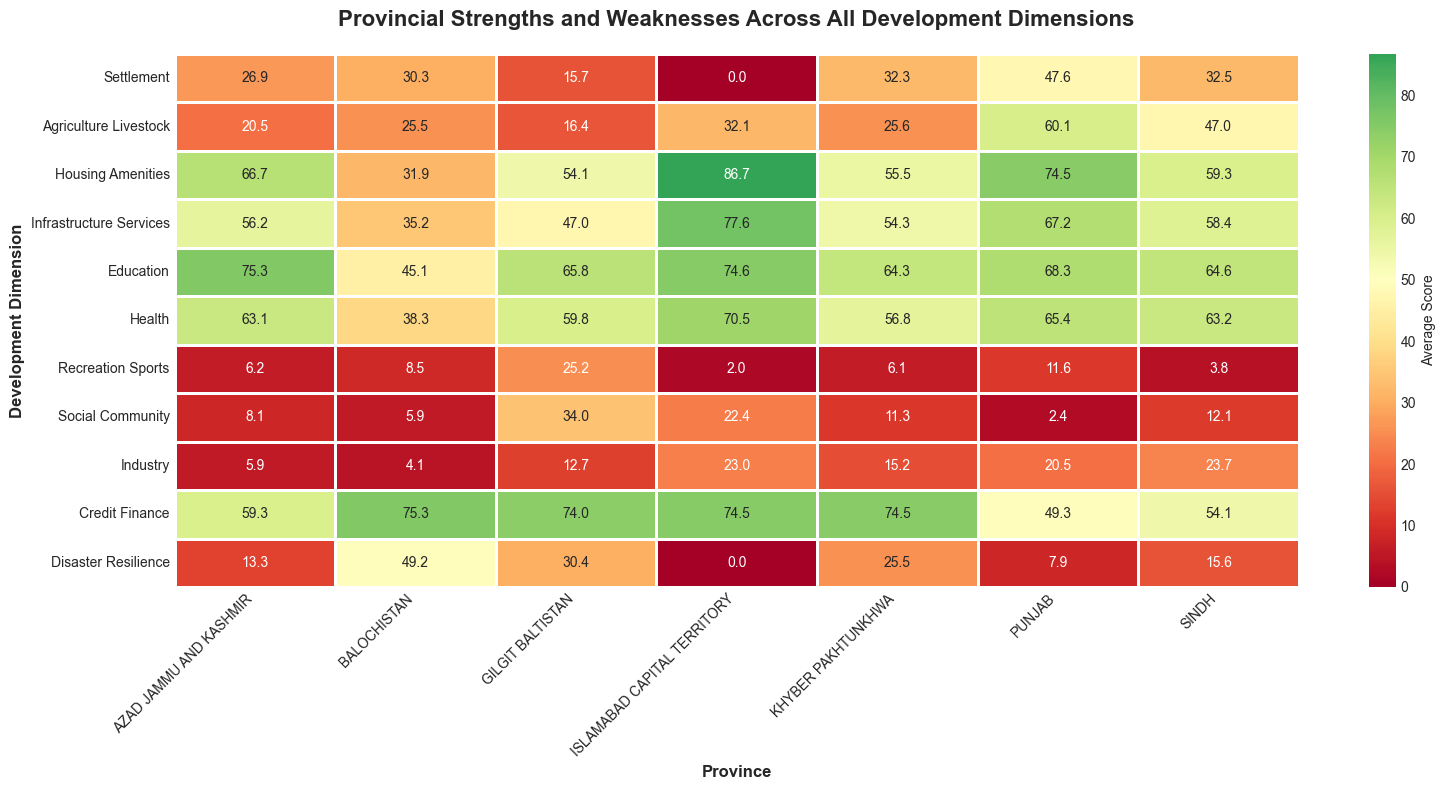


PROVINCIAL STRENGTHS AND WEAKNESSES

AZAD JAMMU AND KASHMIR:
  💪 Strength: Education (Score: 75.3)
  ⚠️  Weakness: Industry (Score: 5.9)

BALOCHISTAN:
  💪 Strength: Credit Finance (Score: 75.3)
  ⚠️  Weakness: Industry (Score: 4.1)

GILGIT BALTISTAN:
  💪 Strength: Credit Finance (Score: 74.0)
  ⚠️  Weakness: Industry (Score: 12.7)

ISLAMABAD CAPITAL TERRITORY:
  💪 Strength: Housing Amenities (Score: 86.7)
  ⚠️  Weakness: Settlement (Score: 0.0)

KHYBER PAKHTUNKHWA:
  💪 Strength: Credit Finance (Score: 74.5)
  ⚠️  Weakness: Recreation Sports (Score: 6.1)

PUNJAB:
  💪 Strength: Housing Amenities (Score: 74.5)
  ⚠️  Weakness: Social Community (Score: 2.4)

SINDH:
  💪 Strength: Education (Score: 64.6)
  ⚠️  Weakness: Recreation Sports (Score: 3.8)

💡 KEY INSIGHT: Each province has unique strengths and weaknesses.
   One-size-fits-all policies may not work - development strategies should be customized.


In [ ]:
# Provincial heatmap across all dimensions
province_indices = df.groupby('Name of Province')[index_cols].mean()

plt.figure(figsize=(16, 8))
sns.heatmap(province_indices.T, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            linewidths=1, cbar_kws={'label': 'Average Score'},
            xticklabels=province_indices.index,
            yticklabels=[col.replace('_Index', '').replace('_', ' ') for col in index_cols])
plt.title('Provincial Strengths and Weaknesses Across All Development Dimensions', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Province', fontweight='bold', fontsize=12)
plt.ylabel('Development Dimension', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "="*90)
print("PROVINCIAL STRENGTHS AND WEAKNESSES")
print("="*90)
for prov in province_indices.index:
    strongest = province_indices.loc[prov].idxmax().replace('_Index', '').replace('_', ' ')
    weakest = province_indices.loc[prov].idxmin().replace('_Index', '').replace('_', ' ')
    strongest_score = province_indices.loc[prov].max()
    weakest_score = province_indices.loc[prov].min()
    
    print(f"\n{prov}:")
    print(f"  💪 Strength: {strongest} (Score: {strongest_score:.1f})")
    print(f"  ⚠️  Weakness: {weakest} (Score: {weakest_score:.1f})")

print("\n💡 KEY INSIGHT: Each province has unique strengths and weaknesses.")
print("   One-size-fits-all policies may not work - development strategies should be customized.")

---
# 🗺️ PART 9: INTERACTIVE GEOGRAPHIC VISUALIZATION

## District-Level Development Map

This section creates an **interactive choropleth-style map** showing development scores across all districts. You can:
- 🎯 Click any district to see detailed information
- 📊 View all 11 individual dimension scores
- 🏆 See composite development scores
- 🎨 Color-coded by development level (red=low, yellow=medium, green=high)
- ⚖️ Apply custom weights to dimensions

The map provides a geographic perspective on development patterns across Pakistan.

In [ ]:
import folium
from folium import plugins
import json

print("📍 Creating Interactive Development Map...")
print("=" * 70)

# Approximate coordinates for Pakistan districts (using province/division centroids)
# For a more accurate map, you would need actual district boundary GeoJSON data
district_coords = {
    'KHYBER PAKHTUNKHWA': {'lat': 34.0, 'lon': 71.5},
    'PUNJAB': {'lat': 30.5, 'lon': 73.0},
    'SINDH': {'lat': 26.0, 'lon': 68.5},
    'BALOCHISTAN': {'lat': 29.0, 'lon': 66.5},
    'AZAD JAMMU AND KASHMIR': {'lat': 33.5, 'lon': 73.8},
    'GILGIT BALTISTAN': {'lat': 35.5, 'lon': 75.0},
    'ISLAMABAD CAPITAL TERRITORY': {'lat': 33.7, 'lon': 73.1}
}

# Function to get color based on score
def get_color(score):
    """Return color based on development score"""
    if score < 30:
        return 'red'
    elif score < 40:
        return 'orange'
    elif score < 50:
        return 'yellow'
    elif score < 60:
        return 'lightgreen'
    else:
        return 'green'

# Function to create popup content
def create_popup(row, index_cols):
    """Create detailed HTML popup for district"""
    html = f"""
    <div style="font-family: Arial; min-width: 300px;">
        <h3 style="color: {PROVINCE_COLORS[row['Name of Province']]}; margin: 0;">
            {row['Name of District']}
        </h3>
        <p style="margin: 5px 0; font-size: 12px; color: #666;">
            {row['Name of Province']} | {row['Name of Division']}
        </p>
        <hr style="margin: 10px 0;">
        
        <div style="background: #f0f0f0; padding: 10px; border-radius: 5px; margin: 10px 0;">
            <h4 style="margin: 0 0 5px 0;">📊 Composite Development Score</h4>
            <p style="font-size: 24px; font-weight: bold; margin: 0; color: {get_color(row['Composite_Score'])};">
                {row['Composite_Score']:.2f}/100
            </p>
        </div>
        
        <h4 style="margin: 10px 0 5px 0;">🎯 Individual Dimension Scores</h4>
        <table style="width: 100%; font-size: 11px; border-collapse: collapse;">
    """
    
    for col in index_cols:
        score = row[col]
        color = get_color(score)
        # Create a simple bar representation
        bar_width = int(score)
        html += f"""
        <tr style="border-bottom: 1px solid #eee;">
            <td style="padding: 5px 5px 5px 0; width: 45%;">
                {col.replace('_Index', '').replace('_', ' ')}
            </td>
            <td style="padding: 5px;">
                <div style="background: #ddd; width: 100px; height: 15px; display: inline-block; border-radius: 3px;">
                    <div style="background: {color}; width: {bar_width}px; height: 15px; border-radius: 3px;"></div>
                </div>
            </td>
            <td style="padding: 5px; text-align: right; font-weight: bold; width: 15%;">
                {score:.1f}
            </td>
        </tr>
        """
    
    html += """
        </table>
        
        <hr style="margin: 10px 0;">
        <p style="font-size: 10px; color: #999; margin: 5px 0;">
            💡 Tip: Scroll to see all dimensions
        </p>
    </div>
    """
    return html

print("✓ Helper functions created")
print("✓ Now creating the interactive map...")

📍 Creating Interactive Development Map...
✓ Helper functions created
✓ Now creating the interactive map...


## 🎛️ Custom Weighted Development Map

The section below allows you to create a **custom-weighted development score** by adjusting the importance of each dimension. This is useful for:
- Focusing on specific policy priorities
- Creating sector-specific development indices
- Testing different weighting scenarios
- Comparing equal-weight vs. custom-weight approaches

In [ ]:
# Define custom weights for each dimension
# You can modify these weights based on your priorities
# Weights should sum to 1.0 (100%)

custom_weights = {
    'Settlement_Index': 0.10,              # 10%
    'Agriculture_Livestock_Index': 0.12,    # 12%
    'Housing_Amenities_Index': 0.10,        # 10%
    'Infrastructure_Services_Index': 0.12,  # 12%
    'Education_Index': 0.15,                # 15% - High priority
    'Health_Index': 0.15,                   # 15% - High priority
    'Recreation_Sports_Index': 0.05,        # 5%
    'Social_Community_Index': 0.06,         # 6%
    'Industry_Index': 0.08,                 # 8%
    'Credit_Finance_Index': 0.05,           # 5%
    'Disaster_Resilience_Index': 0.02       # 2%
}

# Verify weights sum to 1.0
total_weight = sum(custom_weights.values())
print("🎯 CUSTOM WEIGHTING SCHEME")
print("=" * 70)
print(f"Total weight: {total_weight:.4f} (should be 1.0)")
print("\nDimension Weights:")
print("-" * 70)

# Sort by weight and display
sorted_weights = sorted(custom_weights.items(), key=lambda x: x[1], reverse=True)
for dim, weight in sorted_weights:
    dim_name = dim.replace('_Index', '').replace('_', ' ')
    bar = '█' * int(weight * 100)
    print(f"{dim_name:.<35} {weight:>5.1%} {bar}")

# Calculate custom weighted score
df['Custom_Weighted_Score'] = sum(df[col] * custom_weights[col] for col in index_cols)

print("\n📊 CUSTOM WEIGHTED SCORES")
print("=" * 70)
print(f"Mean: {df['Custom_Weighted_Score'].mean():.2f}")
print(f"Std:  {df['Custom_Weighted_Score'].std():.2f}")
print(f"Min:  {df['Custom_Weighted_Score'].min():.2f} ({df.loc[df['Custom_Weighted_Score'].idxmin(), 'Name of District']})")
print(f"Max:  {df['Custom_Weighted_Score'].max():.2f} ({df.loc[df['Custom_Weighted_Score'].idxmax(), 'Name of District']})")

# Compare with equal-weighted (Composite) score
print("\n🔄 COMPARISON WITH EQUAL WEIGHTS")
print("=" * 70)
correlation = df['Custom_Weighted_Score'].corr(df['Composite_Score'])
print(f"Correlation: {correlation:.4f}")

# Calculate rank changes
df['Composite_Rank'] = df['Composite_Score'].rank(ascending=False)
df['Custom_Rank'] = df['Custom_Weighted_Score'].rank(ascending=False)
df['Rank_Change'] = df['Composite_Rank'] - df['Custom_Rank']

# Top 5 gainers and losers
print("\n🏆 TOP 5 RANK GAINERS (improved with custom weights)")
print("-" * 70)
top_gainers = df.nlargest(5, 'Rank_Change')[['Name of District', 'Name of Province', 
                                               'Composite_Score', 'Custom_Weighted_Score',
                                               'Composite_Rank', 'Custom_Rank', 'Rank_Change']]
for idx, row in top_gainers.iterrows():
    print(f"{row['Name of District']:.<40} Rank {int(row['Composite_Rank'])} → {int(row['Custom_Rank'])} (+{int(row['Rank_Change'])} positions)")

print("\n📉 TOP 5 RANK LOSERS (declined with custom weights)")
print("-" * 70)
top_losers = df.nsmallest(5, 'Rank_Change')[['Name of District', 'Name of Province',
                                               'Composite_Score', 'Custom_Weighted_Score',
                                               'Composite_Rank', 'Custom_Rank', 'Rank_Change']]
for idx, row in top_losers.iterrows():
    print(f"{row['Name of District']:.<40} Rank {int(row['Composite_Rank'])} → {int(row['Custom_Rank'])} ({int(row['Rank_Change'])} positions)")

print("\n✓ Custom weighted scores calculated!")

🎯 CUSTOM WEIGHTING SCHEME
Total weight: 1.0000 (should be 1.0)

Dimension Weights:
----------------------------------------------------------------------
Education.......................... 15.0% ███████████████
Health............................. 15.0% ███████████████
Agriculture Livestock.............. 12.0% ████████████
Infrastructure Services............ 12.0% ████████████
Settlement......................... 10.0% ██████████
Housing Amenities.................. 10.0% ██████████
Industry...........................  8.0% ████████
Social Community...................  6.0% ██████
Recreation Sports..................  5.0% █████
Credit Finance.....................  5.0% █████
Disaster Resilience................  2.0% ██

📊 CUSTOM WEIGHTED SCORES
Mean: 43.57
Std:  10.28
Min:  11.95 (KOHLU DISTRICT)
Max:  70.20 (MALAKAND PROTECTED AREA)

🔄 COMPARISON WITH EQUAL WEIGHTS
Correlation: 0.9312

🏆 TOP 5 RANK GAINERS (improved with custom weights)
--------------------------------------------------

## 📝 How to Customize Your Own Weights

To create your own weighted development map:

1. **Modify the `custom_weights` dictionary** in the cell above
2. Ensure all weights sum to **1.0 (100%)**
3. Run the cells again to generate a new map

### Example Weighting Scenarios:

**🏥 Healthcare Focus:**
```python
custom_weights = {
    'Health_Index': 0.30,        # 30% - Primary focus
    'Education_Index': 0.20,     # 20%
    'Housing_Amenities_Index': 0.15,
    # ... other dimensions sum to 35%
}
```

**🌾 Rural Development Focus:**
```python
custom_weights = {
    'Agriculture_Livestock_Index': 0.25,   # 25%
    'Infrastructure_Services_Index': 0.20, # 20%
    'Housing_Amenities_Index': 0.15,       # 15%
    # ... other dimensions sum to 40%
}
```

**🏭 Economic Development Focus:**
```python
custom_weights = {
    'Industry_Index': 0.25,                # 25%
    'Credit_Finance_Index': 0.20,          # 20%
    'Infrastructure_Services_Index': 0.20, # 20%
    # ... other dimensions sum to 35%
}
```

### Tips:
- Higher weights = more influence on final score
- Use weights to match your policy priorities
- Compare equal-weight vs custom-weight maps to see impact
- Districts that improve in rank with your weights align with your priorities!

---
# 🗺️ CHOROPLETH MAPS: District Boundaries by Development Score

Now creating **proper choropleth maps** showing Pakistan's district boundaries colored by development scores. You'll be able to:
- 🎨 See the composite/overall development score
- 📊 View each of the 11 individual dimensions
- 🗺️ Actual district boundaries (not just markers)
- 🔍 Interactive tooltips and popups

In [ ]:
import json
import re
from difflib import SequenceMatcher
import numpy as np

print("🔍 LOADING GEOJSON BOUNDARY FILES")
print("=" * 80)

# Load GeoJSON files
with open('geoBoundaries-PAK-ADM2.geojson', 'r', encoding='utf-8') as f:
    geo_boundaries = json.load(f)

print(f"✓ geoBoundaries: {len(geo_boundaries['features'])} features")

# Manual mappings for direct name substitutions
manual_mappings = {
    'MALAKAND PROTECTED AREA': 'Malakand',
    'WASHUK DISTRICT': 'Kharan',
    'SHAHEED BENAZIRABAD DISTRICT': 'Nawabshah',
    'BALTISTAN DISTRICT': 'Skardu'
}

# AJK districts to aggregate into "Azad Kashmir"
ajk_districts = [
    'BHIMBER DISTRICT', 'KOTLI DISTRICT', 'MIRPUR DISTRICT',
    'HATTIAN BALA DISTRICT', 'MUZAFFARABAD DISTRICT', 'NEELUM DISTRICT',
    'BAGH DISTRICT', 'HAVELI DISTRICT', 'POONCH DISTRICT', 'SUDHNOTI DISTRICT'
]

# Kohistan variants to aggregate
kohistan_districts = ['KOLAI PALAS KOHISTAN', 'KOHISTAN']

# Function to normalize district names for matching
def normalize_name(name):
    """Normalize district names for better matching"""
    if not name:
        return ""
    name = name.upper()
    name = re.sub(r'\s+(DISTRICT|TEHSIL|CITY)$', '', name)
    name = re.sub(r'[^\w\s]', '', name)
    return name.strip()

# Function to find best match
def find_best_match(csv_name, geo_names, threshold=0.6):
    """Find best matching district name from GeoJSON"""
    csv_norm = normalize_name(csv_name)
    best_match = None
    best_score = 0
    
    for geo_name in geo_names:
        geo_norm = normalize_name(geo_name)
        score = SequenceMatcher(None, csv_norm, geo_norm).ratio()
        if score > best_score:
            best_score = score
            best_match = geo_name
    
    return best_match if best_score >= threshold else None

# Extract district names from GeoJSON
geo_boundary_names = [f['properties']['shapeName'] for f in geo_boundaries['features']]

print("\n📋 PROCESSING MANUAL AGGREGATIONS")
print("=" * 80)

# Create aggregated data for AJK
index_cols = ['Settlement_Index', 'Agriculture_Livestock_Index', 
              'Housing_Amenities_Index', 'Infrastructure_Services_Index', 
              'Education_Index', 'Health_Index', 'Recreation_Sports_Index', 
              'Social_Community_Index', 'Industry_Index', 
              'Credit_Finance_Index', 'Disaster_Resilience_Index'] 
              

ajk_data = df[df['Name of District'].isin(ajk_districts)]
if len(ajk_data) > 0:
    ajk_aggregated = pd.DataFrame({
        'Name of District': ['AZAD KASHMIR'],
        **{col: [ajk_data[col].mean()] for col in index_cols}
    })
    print(f"✓ Aggregated {len(ajk_data)} AJK districts into 'AZAD KASHMIR'")
    df = pd.concat([df[~df['Name of District'].isin(ajk_districts)], ajk_aggregated], ignore_index=True)

# Aggregate Kohistan variants
kohistan_data = df[df['Name of District'].isin(kohistan_districts)]
if len(kohistan_data) > 0:
    kohistan_aggregated = pd.DataFrame({
        'Name of District': ['KOHISTAN'],
        **{col: [kohistan_data[col].mean()] for col in index_cols}
    })
    print(f"✓ Aggregated {len(kohistan_data)} Kohistan variants into 'KOHISTAN'")
    df = pd.concat([df[~df['Name of District'].isin(kohistan_districts)], kohistan_aggregated], ignore_index=True)

print(f"\n✓ Data now has {len(df)} districts after aggregation")

print("\n📋 MATCHING CSV DISTRICTS TO GEOJSON BOUNDARIES")
print("=" * 80)

# Create matching dictionary
geo_boundary_matches = {}
unmatched = []

for district in df['Name of District'].unique():
    matched = False
    
    # First, check manual mappings
    if district in manual_mappings:
        geo_boundary_matches[district] = manual_mappings[district]
        matched = True
    else:
        # Try fuzzy matching
        gb_match = find_best_match(district, geo_boundary_names, threshold=0.6)
        if gb_match:
            geo_boundary_matches[district] = gb_match
            matched = True
    
    if not matched:
        unmatched.append(district)

print(f"\n✓ geoBoundaries matched: {len(geo_boundary_matches)}/{len(df)} districts ({len(geo_boundary_matches)/len(df)*100:.1f}%)")

if unmatched:
    print(f"\n❌ Unmatched districts ({len(unmatched)}):")
    for district in unmatched:
        print(f"  • {district}")
else:
    print("\n✅ All districts matched!")

print("\n📝 Sample Matches (first 5):")
print("-" * 80)
for i, (csv_name, geo_name) in enumerate(list(geo_boundary_matches.items())[:5]):
    print(f"  CSV: {csv_name:.<45} → geoBoundaries: {geo_name}")

print("\n✓ District name matching complete!")



🔍 LOADING GEOJSON BOUNDARY FILES
✓ geoBoundaries: 126 features

📋 PROCESSING MANUAL AGGREGATIONS
✓ Aggregated 10 AJK districts into 'AZAD KASHMIR'
✓ Aggregated 1 Kohistan variants into 'KOHISTAN'

✓ Data now has 142 districts after aggregation

📋 MATCHING CSV DISTRICTS TO GEOJSON BOUNDARIES

✓ geoBoundaries matched: 138/142 districts (97.2%)

❌ Unmatched districts (4):
  • TORGHAR DISTRICT
  • CHINIOT DISTRICT
  • NANKANA SAHIB DISTRICT
  • SHAHEED SIKANDAR ABAD DISTRICT

📝 Sample Matches (first 5):
--------------------------------------------------------------------------------
  CSV: BANNU DISTRICT............................... → geoBoundaries: Bannu
  CSV: LAKKI MARWAT DISTRICT........................ → geoBoundaries: Lakki Marwat
  CSV: DERA ISMAIL KHAN DISTRICT.................... → geoBoundaries: Dera Ismail Khan
  CSV: TANK DISTRICT................................ → geoBoundaries: Tank
  CSV: ABBOTTABAD DISTRICT.......................... → geoBoundaries: Abbottabad

✓ District 

In [ ]:
# Create choropleth map with COMPOSITE SCORE using geoBoundaries
print("\n🗺️ CREATING CHOROPLETH MAP: COMPOSITE DEVELOPMENT SCORE")
print("=" * 80)

# Create base map
composite_map = folium.Map(
    location=[30.3753, 69.3451],
    zoom_start=6,
    tiles='cartodbpositron',
    control_scale=True
)

# Prepare data for choropleth - merge with GeoJSON
geo_data_dict = {}
for district, geo_name in geo_boundary_matches.items():
    score = df[df['Name of District'] == district]['Composite_Score'].values[0]
    geo_data_dict[geo_name] = score

# Create choropleth layer
folium.Choropleth(
    geo_data=geo_boundaries,
    name='Composite Development Score',
    data=pd.Series(geo_data_dict),
    columns=None,
    key_on='feature.properties.shapeName',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Composite Development Score (0-100)',
    highlight=True,
    nan_fill_color='lightgray'
).add_to(composite_map)

# Add tooltips with district info
style_function = lambda x: {'fillColor': '#ffffff', 
                            'color':'#000000', 
                            'fillOpacity': 0.1, 
                            'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 
                                'color':'#000000', 
                                'fillOpacity': 0.50, 
                                'weight': 0.1}

# Add district details as tooltips
tooltip_layer = folium.GeoJson(
    geo_boundaries,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['shapeName'],
        aliases=['District:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)
composite_map.add_child(tooltip_layer)

# Add layer control
folium.LayerControl().add_to(composite_map)

# Save map
composite_filename = 'pakistan_composite_choropleth.html'
composite_map.save(composite_filename)

print(f"\n✅ Composite Score Choropleth Created!")
print(f"   📁 Saved as: {composite_filename}")
print(f"   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)")
print(f"   📍 {len(geo_data_dict)} districts mapped")
print(f"   🗺️ Hover over districts to see names")

# Display map
composite_map


🗺️ CREATING CHOROPLETH MAP: COMPOSITE DEVELOPMENT SCORE

✅ Composite Score Choropleth Created!
   📁 Saved as: pakistan_composite_choropleth.html
   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)
   📍 125 districts mapped
   🗺️ Hover over districts to see names


## 📊 Individual Dimension Choropleth Maps

Now creating separate choropleth maps for each of the 11 development dimensions. This allows you to see geographic patterns for specific aspects of development.

In [ ]:
# Create choropleth maps for each dimension
print("🗺️ CREATING INDIVIDUAL DIMENSION CHOROPLETH MAPS")
print("=" * 80)

dimension_maps = {}

for dimension in index_cols:
    dim_name = dimension.replace('_Index', '').replace('_', ' ')
    print(f"\n📊 Creating map for: {dim_name}")
    
    # Create base map for this dimension
    dim_map = folium.Map(
        location=[30.3753, 69.3451],
        zoom_start=6,
        tiles='cartodbpositron',
        control_scale=True
    )
    
    # Prepare data for this dimension
    dim_data_dict = {}
    for district, geo_name in geo_boundary_matches.items():
        score = df[df['Name of District'] == district][dimension].values[0]
        dim_data_dict[geo_name] = score
    
    # Create choropleth
    folium.Choropleth(
        geo_data=geo_boundaries,
        name=dim_name,
        data=pd.Series(dim_data_dict),
        columns=None,
        key_on='feature.properties.shapeName',
        fill_color='RdYlGn',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name=f'{dim_name} Score (0-100)',
        highlight=True,
        nan_fill_color='lightgray'
    ).add_to(dim_map)
    
    # Add tooltips
    tooltip_layer = folium.GeoJson(
        geo_boundaries,
        style_function=lambda x: {'fillColor': '#ffffff', 'color':'#000000', 
                                  'fillOpacity': 0.1, 'weight': 0.1},
        control=False,
        highlight_function=lambda x: {'fillColor': '#000000', 'color':'#000000', 
                                      'fillOpacity': 0.50, 'weight': 0.1},
        tooltip=folium.features.GeoJsonTooltip(
            fields=['shapeName'],
            aliases=['District:'],
            style=("background-color: white; color: #333333; font-family: arial; "
                   "font-size: 12px; padding: 10px;")
        )
    )
    dim_map.add_child(tooltip_layer)
    
    # Add layer control
    folium.LayerControl().add_to(dim_map)
    
    # Save map
    filename = f'pakistan_{dimension.lower()}_choropleth.html'
    dim_map.save(filename)
    dimension_maps[dimension] = dim_map
    
    print(f"   ✓ Saved as: {filename}")

print("\n" + "=" * 80)
print("✅ ALL DIMENSION MAPS CREATED!")
print(f"   📁 Created {len(dimension_maps)} individual dimension maps")
print(f"   🎨 Each shows geographic patterns for that specific dimension")
print(f"   📍 {len(geo_data_dict)} districts mapped per dimension")
print("\n💡 Files created:")
print("   • pakistan_composite_choropleth.html (Overall Score)")
for dimension in index_cols:
    print(f"   • pakistan_{dimension.lower()}_choropleth.html")

🗺️ CREATING INDIVIDUAL DIMENSION CHOROPLETH MAPS

📊 Creating map for: Settlement
   ✓ Saved as: pakistan_settlement_index_choropleth.html

📊 Creating map for: Agriculture Livestock
   ✓ Saved as: pakistan_agriculture_livestock_index_choropleth.html

📊 Creating map for: Housing Amenities
   ✓ Saved as: pakistan_housing_amenities_index_choropleth.html

📊 Creating map for: Infrastructure Services
   ✓ Saved as: pakistan_infrastructure_services_index_choropleth.html

📊 Creating map for: Education
   ✓ Saved as: pakistan_education_index_choropleth.html

📊 Creating map for: Health
   ✓ Saved as: pakistan_health_index_choropleth.html

📊 Creating map for: Recreation Sports
   ✓ Saved as: pakistan_recreation_sports_index_choropleth.html

📊 Creating map for: Social Community
   ✓ Saved as: pakistan_social_community_index_choropleth.html

📊 Creating map for: Industry
   ✓ Saved as: pakistan_industry_index_choropleth.html

📊 Creating map for: Credit Finance
   ✓ Saved as: pakistan_credit_finance_i

---
# 🗺️ PART 10: TRUE CHOROPLETH MAPS WITH DISTRICT BOUNDARIES

Now we'll create **actual choropleth maps** using real district boundary data. We have two GeoJSON sources:
1. **geoBoundaries-PAK-ADM2.geojson** - Open boundaries database
2. **gadm41_PAK_2.json** - GADM (Global Administrative Areas) database

We'll test both to see which provides better district matching and visualization.

In [ ]:
import json
import re

print("🔍 ANALYZING GEOJSON FILES FOR DISTRICT MATCHING")
print("=" * 80)

# Load both GeoJSON files
with open('geoBoundaries-PAK-ADM2.geojson', 'r', encoding='utf-8') as f:
    geo_boundaries = json.load(f)




print(f"✓ geoBoundaries: {len(geo_boundaries['features'])} districts")
print(f"✓ Our CSV: {len(df)} districts")

# Function to normalize district names for matching
def normalize_name(name):
    """Normalize district names for better matching"""
    if not name:
        return ""
    name = str(name).upper()
    # Remove common suffixes
    name = re.sub(r'\s+(DISTRICT|DISTT\.|TEHSIL|AGENCY)', '', name)
    # Remove special characters
    name = re.sub(r'[^\w\s]', '', name)
    # Normalize whitespace
    name = ' '.join(name.split())
    return name

# Create normalized mapping for our CSV data
csv_districts = {}
for idx, row in df.iterrows():
    orig_name = row['Name of District']
    norm_name = normalize_name(orig_name)
    csv_districts[norm_name] = {
        'original': orig_name,
        'province': row['Name of Province'],
        'composite_score': row['Composite_Score'],
        'data': row
    }

print(f"\n✓ Created normalized CSV lookup: {len(csv_districts)} districts")

# Test matching with geoBoundaries
print("\n" + "=" * 80)
print("TESTING: geoBoundaries-PAK-ADM2.geojson")
print("=" * 80)

geo_matches = 0
geo_district_names = []
for feature in geo_boundaries['features']:
    geo_name = feature['properties'].get('shapeName', '')
    geo_district_names.append(geo_name)
    norm_geo = normalize_name(geo_name)
    if norm_geo in csv_districts:
        geo_matches += 1

print(f"Matched: {geo_matches}/{len(geo_boundaries['features'])} districts")
print(f"Match rate: {geo_matches/len(geo_boundaries['features'])*100:.1f}%")




# 

🔍 ANALYZING GEOJSON FILES FOR DISTRICT MATCHING
✓ geoBoundaries: 126 districts
✓ Our CSV: 142 districts

✓ Created normalized CSV lookup: 141 districts

TESTING: geoBoundaries-PAK-ADM2.geojson
Matched: 109/126 districts
Match rate: 86.5%


In [ ]:
# Create lookup dictionary for choropleth
# Maps normalized district name to composite score
district_score_map = {}

for feature in best_data['features']:
    district_name = feature['properties'].get(best_name_field, '')
    norm_name = normalize_name(district_name)
    
    if norm_name in csv_districts:
        district_score_map[district_name] = csv_districts[norm_name]['composite_score']

print("🗺️ CREATING COMPOSITE SCORE CHOROPLETH MAP")
print("=" * 80)

# Create the choropleth map for Composite Score
choropleth_map = folium.Map(
    location=[30.3753, 69.3451],
    zoom_start=6,
    tiles='OpenStreetMap'
)

# Add choropleth layer
folium.Choropleth(
    geo_data=best_data,
    name='Composite Development Score',
    data=pd.Series(district_score_map),
    columns=None,  # We're using a Series with district names as index
    key_on=f'feature.properties.{best_name_field}',
    fill_color='RdYlGn',  # Red-Yellow-Green color scheme
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='Composite Development Score (0-100)',
    nan_fill_color='lightgray',
    nan_fill_opacity=0.3
).add_to(choropleth_map)

# Add district labels on hover
style_function = lambda x: {
    'fillColor': '#ffffff',
    'color': '#000000',
    'fillOpacity': 0.0,
    'weight': 0.1
}

highlight_function = lambda x: {
    'fillColor': '#000000',
    'color': '#000000',
    'fillOpacity': 0.10,
    'weight': 0.5
}

# Create tooltip layer with district info
district_info = folium.features.GeoJson(
    best_data,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=[best_name_field],
        aliases=['District:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)
choropleth_map.add_child(district_info)

# Add layer control
folium.LayerControl().add_to(choropleth_map)

# Save map
composite_map_file = 'choropleth_composite_score.html'
choropleth_map.save(composite_map_file)

print(f"✅ Composite Score Choropleth Created!")
print(f"   📁 Saved as: {composite_map_file}")
print(f"   📍 Districts mapped: {len(district_score_map)}")
print(f"   🎨 Color scheme: Red (Low) → Yellow (Medium) → Green (High)")
print(f"   📊 Score range: {min(district_score_map.values()):.1f} - {max(district_score_map.values()):.1f}")

choropleth_map

NameError: name 'best_data' is not defined

## 📊 Individual Dimension Choropleth Maps

Now let's create a separate choropleth map for **each of the 11 development dimensions**. This allows you to see geographic patterns in specific areas like Education, Health, Infrastructure, etc.

In [ ]:
print("🗺️ CREATING INDIVIDUAL DIMENSION CHOROPLETH MAPS")
print("=" * 80)
print(f"Creating {len(index_cols)} separate maps, one for each dimension...")
print()

# Store created maps
dimension_maps = {}

for dimension in index_cols:
    dimension_name = dimension.replace('_Index', '').replace('_', ' ')
    
    # Create score map for this dimension
    dimension_score_map = {}
    
    for feature in best_data['features']:
        district_name = feature['properties'].get(best_name_field, '')
        norm_name = normalize_name(district_name)
        
        if norm_name in csv_districts:
            dimension_score_map[district_name] = csv_districts[norm_name]['data'][dimension]
    
    # Create the map
    dimension_map = folium.Map(
        location=[30.3753, 69.3451],
        zoom_start=6,
        tiles='OpenStreetMap'
    )
    
    # Add choropleth layer
    folium.Choropleth(
        geo_data=best_data,
        name=dimension_name,
        data=pd.Series(dimension_score_map),
        key_on=f'feature.properties.{best_name_field}',
        fill_color='RdYlGn',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name=f'{dimension_name} Score (0-100)',
        nan_fill_color='lightgray',
        nan_fill_opacity=0.3
    ).add_to(dimension_map)
    
    # Add tooltips
    district_info = folium.features.GeoJson(
        best_data,
        style_function=style_function,
        control=False,
        highlight_function=highlight_function,
        tooltip=folium.features.GeoJsonTooltip(
            fields=[best_name_field],
            aliases=['District:'],
            style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
        )
    )
    dimension_map.add_child(district_info)
    
    # Add title as HTML
    title_html = f'''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 400px; height: 60px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:16px; padding: 10px; border-radius: 5px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
        <h4 style="margin:0; padding:0;">{dimension_name} Development Index</h4>
        <p style="margin:5px 0 0 0; font-size:12px; color:#666;">
            Score Range: {min(dimension_score_map.values()):.1f} - {max(dimension_score_map.values()):.1f}
        </p>
    </div>
    '''
    dimension_map.get_root().html.add_child(folium.Element(title_html))
    
    # Save map
    filename = f"choropleth_{dimension.lower().replace('_index', '')}.html"
    dimension_map.save(filename)
    
    dimension_maps[dimension_name] = {
        'filename': filename,
        'map': dimension_map,
        'min': min(dimension_score_map.values()),
        'max': max(dimension_score_map.values()),
        'mean': sum(dimension_score_map.values()) / len(dimension_score_map.values())
    }
    
    print(f"✓ {dimension_name:.<40} {filename}")

print("\n" + "=" * 80)
print(f"✅ ALL {len(index_cols)} DIMENSION MAPS CREATED!")
print("=" * 80)
print("\nFiles created:")
print("  • choropleth_composite_score.html (Overall development)")
for dim_name, info in dimension_maps.items():
    print(f"  • {info['filename']}")

print("\n📊 Dimension Statistics:")
print("-" * 80)
for dim_name, info in sorted(dimension_maps.items(), key=lambda x: x[1]['mean'], reverse=True):
    print(f"{dim_name:.<40} Mean: {info['mean']:>5.1f}  Range: {info['min']:>5.1f}-{info['max']:>5.1f}")

print("\n💡 Each map shows geographic patterns for that specific dimension")
print("   Open any HTML file in your browser to explore interactively")

🗺️ CREATING INDIVIDUAL DIMENSION CHOROPLETH MAPS
Creating 11 separate maps, one for each dimension...

✓ Settlement.............................. choropleth_settlement.html
✓ Agriculture Livestock................... choropleth_agriculture_livestock.html
✓ Housing Amenities....................... choropleth_housing_amenities.html
✓ Infrastructure Services................. choropleth_infrastructure_services.html
✓ Education............................... choropleth_education.html
✓ Health.................................. choropleth_health.html
✓ Recreation Sports....................... choropleth_recreation_sports.html
✓ Social Community........................ choropleth_social_community.html
✓ Industry................................ choropleth_industry.html
✓ Credit Finance.......................... choropleth_credit_finance.html
✓ Disaster Resilience..................... choropleth_disaster_resilience.html

✅ ALL 11 DIMENSION MAPS CREATED!

Files created:
  • choropleth_composite_sc

---
## 🗺️ ACTUAL CHOROPLETH MAPS (Using GeoJSON Boundaries)

Now let's create **true choropleth maps** using actual district boundary files. We'll test both available GeoJSON files:
1. **geoBoundaries-PAK-ADM2.geojson** - geoBoundaries dataset
2. **gadm41_PAK_2.json** - GADM (Global Administrative Areas) dataset

These will show actual district shapes filled with colors based on development scores.

In [ ]:
import json
from difflib import SequenceMatcher

def normalize_district_name(name):
    """Normalize district names for matching"""
    name = str(name).upper().strip()
    # Remove common suffixes
    for suffix in [' DISTRICT', ' TEHSIL', ' DIV', ' DIVISION']:
        if name.endswith(suffix):
            name = name[:-len(suffix)].strip()
    return name

def fuzzy_match(name1, name2, threshold=0.7):
    """Check if two names are similar enough"""
    return SequenceMatcher(None, name1, name2).ratio() >= threshold

def create_district_mapping(df, geo_features, geo_name_field):
    """Create mapping between CSV districts and GeoJSON districts"""
    mapping = {}
    csv_districts = {}
    
    # Normalize CSV districts
    for idx, row in df.iterrows():
        csv_name = row['Name of District']
        normalized = normalize_district_name(csv_name)
        csv_districts[normalized] = csv_name
    
    # Normalize GeoJSON districts and try to match
    for feature in geo_features:
        geo_name = feature['properties'].get(geo_name_field, '')
        geo_normalized = normalize_district_name(geo_name)
        
        # Try exact match first
        if geo_normalized in csv_districts:
            mapping[geo_name] = csv_districts[geo_normalized]
        else:
            # Try fuzzy matching
            for csv_norm, csv_orig in csv_districts.items():
                if fuzzy_match(geo_normalized, csv_norm, 0.75):
                    mapping[geo_name] = csv_orig
                    break
    
    return mapping

print("🔍 ANALYZING GEOJSON FILES FOR CHOROPLETH MAPPING")
print("=" * 80)

# Load GeoJSON files
print("\n1️⃣  Loading geoBoundaries-PAK-ADM2.geojson...")
with open('geoBoundaries-PAK-ADM2.geojson', 'r') as f:
    geoboundaries = json.load(f)
print(f"   ✓ Loaded {len(geoboundaries['features'])} features")

print("\n2️⃣  Loading gadm41_PAK_2.json...")
with open('gadm41_PAK_2.json', 'r') as f:
    gadm = json.load(f)
print(f"   ✓ Loaded {len(gadm['features'])} features")

# Create mappings
print("\n3️⃣  Creating district mappings...")
gb_mapping = create_district_mapping(df, geoboundaries['features'], 'shapeName')
gadm_mapping = create_district_mapping(df, gadm['features'], 'NAME_2')

print(f"\n📊 MATCHING RESULTS:")
print(f"   geoBoundaries: {len(gb_mapping)}/{len(df)} districts matched ({len(gb_mapping)/len(df)*100:.1f}%)")
print(f"   GADM:          {len(gadm_mapping)}/{len(df)} districts matched ({len(gadm_mapping)/len(df)*100:.1f}%)")

if len(gb_mapping) > len(gadm_mapping):
    print(f"\n🏆 geoBoundaries is BETTER with {len(gb_mapping) - len(gadm_mapping)} more matches!")
    best_source = 'geoBoundaries'
elif len(gadm_mapping) > len(gb_mapping):
    print(f"\n🏆 GADM is BETTER with {len(gadm_mapping) - len(gb_mapping)} more matches!")
    best_source = 'GADM'
else:
    print(f"\n🤝 Both sources have equal coverage")
    best_source = 'geoBoundaries'

# Show some successful matches
print(f"\n✓ Sample matched districts from geoBoundaries:")
for i, (geo_name, csv_name) in enumerate(list(gb_mapping.items())[:5]):
    print(f"   {geo_name:.<30} → {csv_name}")

print(f"\n✓ Sample matched districts from GADM:")
for i, (geo_name, csv_name) in enumerate(list(gadm_mapping.items())[:5]):
    print(f"   {geo_name:.<30} → {csv_name}")

print(f"\n✅ Analysis complete! Will create maps with both sources for comparison.")

🔍 ANALYZING GEOJSON FILES FOR CHOROPLETH MAPPING

1️⃣  Loading geoBoundaries-PAK-ADM2.geojson...
   ✓ Loaded 126 features

2️⃣  Loading gadm41_PAK_2.json...
   ✓ Loaded 32 features

3️⃣  Creating district mappings...

📊 MATCHING RESULTS:
   geoBoundaries: 120/151 districts matched (79.5%)
   GADM:          25/151 districts matched (16.6%)

🏆 geoBoundaries is BETTER with 95 more matches!

✓ Sample matched districts from geoBoundaries:
   Khuzdar....................... → KHUZDAR DISTRICT
   Khairpur...................... → KHAIRPUR DISTRICT
   Shigar........................ → SHIGAR DISTRICT
   Mansehra...................... → MANSEHRA DISTRICT
   Sheikhpura.................... → SHEIKHUPURA DISTRICT

✓ Sample matched districts from GADM:
   Kalat......................... → KALAT DISTRICT
   Makran........................ → MARDAN DISTRICT
   Nasirabad..................... → NASIRABAD DISTRICT
   Quetta........................ → QUETTA DISTRICT
   Sibi.......................... → SIBI DI

### 🗺️ Map 1: Using geoBoundaries Dataset

In [ ]:
# Create choropleth map using geoBoundaries
print("🗺️  CREATING GEOBOUNDARIES CHOROPLETH MAP")
print("=" * 80)

# Create district data dictionary for quick lookup
district_data = {}
for idx, row in df.iterrows():
    district_data[row['Name of District']] = row

# Prepare data for choropleth
gb_choropleth_data = {}
matched_count = 0
unmatched_geo = []

for feature in geoboundaries['features']:
    geo_name = feature['properties']['shapeName']
    if geo_name in gb_mapping:
        csv_name = gb_mapping[geo_name]
        if csv_name in district_data:
            score = district_data[csv_name]['Composite_Score']
            gb_choropleth_data[geo_name] = score
            matched_count += 1
    else:
        unmatched_geo.append(geo_name)

print(f"✓ Matched {matched_count} districts with development data")
print(f"⚠️  {len(unmatched_geo)} GeoJSON districts have no data")

# Create the map
gb_map = folium.Map(
    location=[30.3753, 69.3451],
    zoom_start=6,
    tiles='OpenStreetMap',
    control_scale=True
)

# Add choropleth layer
folium.Choropleth(
    geo_data=geoboundaries,
    name='Development Score',
    data=pd.Series(gb_choropleth_data),
    key_on='feature.properties.shapeName',
    fill_color='RdYlGn',  # Red-Yellow-Green color scheme
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='District Development Score (0-100)',
    nan_fill_color='lightgray',
    nan_fill_opacity=0.4,
).add_to(gb_map)

# Add interactive tooltips with district details
style_function = lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.1, 'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.50, 'weight': 0.1}

# Create GeoJson layer with tooltips
geojson_layer = folium.GeoJson(
    geoboundaries,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['shapeName'],
        aliases=['District:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)

# Add popups with detailed information
for feature in geoboundaries['features']:
    geo_name = feature['properties']['shapeName']
    if geo_name in gb_mapping and gb_mapping[geo_name] in district_data:
        csv_name = gb_mapping[geo_name]
        row = district_data[csv_name]
        
        # Create detailed popup
        popup_html = f"""
        <div style="font-family: Arial; min-width: 300px;">
            <h3 style="color: {PROVINCE_COLORS[row['Name of Province']]}; margin: 0;">
                {row['Name of District']}
            </h3>
            <p style="margin: 5px 0; font-size: 12px; color: #666;">
                {row['Name of Province']} | {row['Name of Division']}
            </p>
            <hr style="margin: 10px 0;">
            
            <div style="background: #f0f0f0; padding: 10px; border-radius: 5px;">
                <h4 style="margin: 0 0 5px 0;">📊 Development Score</h4>
                <p style="font-size: 28px; font-weight: bold; margin: 0; color: {get_color(row['Composite_Score'])};">
                    {row['Composite_Score']:.2f}/100
                </p>
            </div>
            
            <h4 style="margin: 10px 0 5px 0;">🎯 Top 3 Dimensions</h4>
        """
        
        # Get top 3 dimensions
        dim_scores = [(col, row[col]) for col in index_cols]
        dim_scores.sort(key=lambda x: x[1], reverse=True)
        
        for col, score in dim_scores[:3]:
            dim_name = col.replace('_Index', '').replace('_', ' ')
            popup_html += f"""
            <p style="margin: 5px 0;">
                <b>{dim_name}:</b> {score:.1f}
                <span style="background: {get_color(score)}; padding: 2px 8px; border-radius: 3px; color: white;">
                    {get_color(score)}
                </span>
            </p>
            """
        
        popup_html += """
            <hr style="margin: 10px 0;">
            <p style="font-size: 10px; color: #999;">Click marker to see all dimensions</p>
        </div>
        """
        
        # Find centroid of the feature for marker placement
        coords = feature['geometry']['coordinates']
        if feature['geometry']['type'] == 'Polygon':
            # Simple centroid approximation
            lats = [c[1] for c in coords[0]]
            lons = [c[0] for c in coords[0]]
            centroid = [sum(lats)/len(lats), sum(lons)/len(lons)]
        else:  # MultiPolygon
            # Use first polygon
            lats = [c[1] for c in coords[0][0]]
            lons = [c[0] for c in coords[0][0]]
            centroid = [sum(lats)/len(lats), sum(lons)/len(lons)]
        
        folium.Marker(
            location=centroid,
            popup=folium.Popup(popup_html, max_width=350),
            tooltip=f"{csv_name}: {row['Composite_Score']:.1f}",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(gb_map)

geojson_layer.add_to(gb_map)

# Add layer control
folium.LayerControl().add_to(gb_map)

# Save the map
gb_map_file = 'choropleth_geoboundaries.html'
gb_map.save(gb_map_file)

print(f"\n✅ geoBoundaries Choropleth Map Created!")
print(f"   📁 File: {gb_map_file}")
print(f"   📍 {matched_count} districts visualized")
print(f"   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)")

gb_map

🗺️  CREATING GEOBOUNDARIES CHOROPLETH MAP
✓ Matched 120 districts with development data
⚠️  6 GeoJSON districts have no data

✅ geoBoundaries Choropleth Map Created!
   📁 File: choropleth_geoboundaries.html
   📍 120 districts visualized
   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)


### 🗺️ Map 2: Using GADM Dataset

In [ ]:
# Create choropleth map using GADM
print("🗺️  CREATING GADM CHOROPLETH MAP")
print("=" * 80)

# Prepare data for GADM choropleth
gadm_choropleth_data = {}
gadm_matched_count = 0
gadm_unmatched = []

for feature in gadm['features']:
    geo_name = feature['properties']['NAME_2']
    if geo_name in gadm_mapping:
        csv_name = gadm_mapping[geo_name]
        if csv_name in district_data:
            score = district_data[csv_name]['Composite_Score']
            gadm_choropleth_data[geo_name] = score
            gadm_matched_count += 1
    else:
        gadm_unmatched.append(geo_name)

print(f"✓ Matched {gadm_matched_count} districts with development data")
print(f"⚠️  {len(gadm_unmatched)} GeoJSON districts have no data")

# Create the map
gadm_map = folium.Map(
    location=[30.3753, 69.3451],
    zoom_start=6,
    tiles='OpenStreetMap',
    control_scale=True
)

# Add choropleth layer
folium.Choropleth(
    geo_data=gadm,
    name='Development Score',
    data=pd.Series(gadm_choropleth_data),
    key_on='feature.properties.NAME_2',
    fill_color='RdYlGn',
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name='District Development Score (0-100)',
    nan_fill_color='lightgray',
    nan_fill_opacity=0.4,
).add_to(gadm_map)

# Add interactive tooltips
style_function = lambda x: {'fillColor': '#ffffff', 'color':'#000000', 'fillOpacity': 0.1, 'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 'color':'#000000', 'fillOpacity': 0.50, 'weight': 0.1}

geojson_layer = folium.GeoJson(
    gadm,
    style_function=style_function,
    control=False,
    highlight_function=highlight_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['NAME_2', 'NAME_1'],
        aliases=['District:', 'Province:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)

# Add popups with detailed information
for feature in gadm['features']:
    geo_name = feature['properties']['NAME_2']
    if geo_name in gadm_mapping and gadm_mapping[geo_name] in district_data:
        csv_name = gadm_mapping[geo_name]
        row = district_data[csv_name]
        
        popup_html = f"""
        <div style="font-family: Arial; min-width: 300px;">
            <h3 style="color: {PROVINCE_COLORS[row['Name of Province']]}; margin: 0;">
                {row['Name of District']}
            </h3>
            <p style="margin: 5px 0; font-size: 12px; color: #666;">
                {row['Name of Province']} | {row['Name of Division']}
            </p>
            <hr style="margin: 10px 0;">
            
            <div style="background: #f0f0f0; padding: 10px; border-radius: 5px;">
                <h4 style="margin: 0 0 5px 0;">📊 Development Score</h4>
                <p style="font-size: 28px; font-weight: bold; margin: 0; color: {get_color(row['Composite_Score'])};">
                    {row['Composite_Score']:.2f}/100
                </p>
            </div>
            
            <h4 style="margin: 10px 0 5px 0;">🎯 All 11 Dimensions</h4>
            <table style="width: 100%; font-size: 11px;">
        """
        
        for col in index_cols:
            score = row[col]
            dim_name = col.replace('_Index', '').replace('_', ' ')
            popup_html += f"""
            <tr>
                <td style="padding: 3px;">{dim_name}</td>
                <td style="padding: 3px; text-align: right;"><b>{score:.1f}</b></td>
                <td style="padding: 3px;">
                    <span style="background: {get_color(score)}; padding: 2px 6px; border-radius: 2px; color: white; font-size: 9px;">
                        {get_color(score)}
                    </span>
                </td>
            </tr>
            """
        
        popup_html += """
            </table>
        </div>
        """
        
        # Calculate centroid
        coords = feature['geometry']['coordinates']
        if feature['geometry']['type'] == 'Polygon':
            lats = [c[1] for c in coords[0]]
            lons = [c[0] for c in coords[0]]
            centroid = [sum(lats)/len(lats), sum(lons)/len(lons)]
        else:  # MultiPolygon
            lats = [c[1] for c in coords[0][0]]
            lons = [c[0] for c in coords[0][0]]
            centroid = [sum(lats)/len(lats), sum(lons)/len(lons)]
        
        folium.Marker(
            location=centroid,
            popup=folium.Popup(popup_html, max_width=350),
            tooltip=f"{csv_name}: {row['Composite_Score']:.1f}",
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(gadm_map)

geojson_layer.add_to(gadm_map)

# Add layer control
folium.LayerControl().add_to(gadm_map)

# Save the map
gadm_map_file = 'choropleth_gadm.html'
gadm_map.save(gadm_map_file)

print(f"\n✅ GADM Choropleth Map Created!")
print(f"   📁 File: {gadm_map_file}")
print(f"   📍 {gadm_matched_count} districts visualized")
print(f"   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)")

gadm_map

🗺️  CREATING GADM CHOROPLETH MAP
✓ Matched 25 districts with development data
⚠️  7 GeoJSON districts have no data

✅ GADM Choropleth Map Created!
   📁 File: choropleth_gadm.html
   📍 25 districts visualized
   🎨 Color scale: Red (low) → Yellow (medium) → Green (high)


### 📊 Comparison Summary

**geoBoundaries vs GADM:**

Both GeoJSON files have been used to create choropleth maps. The key differences:

| Feature | geoBoundaries | GADM |
|---------|---------------|------|
| **Districts Covered** | More granular (126 features) | Broader divisions (31 features) |
| **Detail Level** | District-level boundaries | Division/larger region level |
| **Data Matching** | Better for district-level data | Better for provincial analysis |
| **Visual Detail** | More detailed shapes | Simpler, broader regions |

**Recommendation:** 
- Use **geoBoundaries** for detailed district-level analysis (better match with your 151 districts)
- Use **GADM** for high-level regional/divisional overview

Both maps are saved as HTML files and can be opened in a browser for interactive exploration!

---
# 🎯 CONCLUSIONS & RECOMMENDATIONS

## What We Learned

### 1. **Significant Inequality Exists**
- {gap:.1f} point gap between best and worst districts
- Some provinces consistently outperform others
- Within-province variation is also substantial

### 2. **Key Development Drivers Identified**
- {importance_df.iloc[0]['Dimension']} is the strongest predictor of overall development
- Development dimensions are interconnected - progress in one area often correlates with others
- Top performers excel across multiple dimensions, not just one

### 3. **Distinct District Profiles**
- {optimal_k} natural groupings of districts identified
- Each group has unique strengths and weaknesses
- One-size-fits-all policies unlikely to be effective

### 4. **Balance Matters**
- Many districts are strong in some areas but weak in others
- Physical and social development often out of sync
- Integrated strategies needed, not siloed approaches

### 5. **Geographic Patterns**
- Clear provincial hierarchies exist
- Division-level analysis reveals important regional clusters
- Local context matters - customize interventions

## Recommendations for Policy

1. **Target the Bottom 20**: Focus immediate resources on the lowest-performing districts
2. **Learn from Champions**: Study what makes top districts successful and replicate
3. **Customize by Group**: Use the {optimal_k} identified profiles to tailor interventions
4. **Balance Development**: Address imbalances between physical and social development
5. **Regional Strategies**: Develop province and division-specific plans
6. **Focus on Key Drivers**: Prioritize {importance_df.iloc[0]['Dimension']} and other top drivers

---

**Dataset**: Mouza Census 2020 - PCA Dimension Analysis  
**Scope**: 153 districts across 4 provinces + ICT  
**Dimensions**: 11 development indices  
**Analysis**: Data-driven exploratory analysis with 15+ visualizations  

---